# Proyecto Final - Data Science III: NLP & Deep Learning

**Alumno:** [Rasquetti, Nehuen Juan Alfredo]  
**Fecha:** Mayo 2026  
**Curso:** Data Science III - [Coder House]

---

## Descripción del problema de negocio

Las aerolíneas reciben diariamente miles de menciones en redes sociales por
parte de sus pasajeros. Detectar manualmente cuáles de esos mensajes contienen
opiniones negativas (quejas, reclamos) es inviable a escala. En este proyecto
desarrollaremos un modelo capaz de clasificar automáticamente tweets dirigidos a
aerolíneas estadounidenses como **positivos** o **negativos**, lo que permitiría
al área de atención al cliente priorizar la respuesta a los casos críticos.

## Objetivo general

Construir un modelo de clasificación binaria de texto que, a partir del
contenido de un tweet, prediga si la opinión del usuario es positiva o negativa,
aplicando técnicas de Procesamiento de Lenguaje Natural y Machine Learning.

## Origen de los datos

Dataset público **"Twitter US Airline Sentiment"** publicado en Kaggle:
- Fuente original: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment
- Autor: CrowdFlower (ahora Appen)
- Licencia: CC BY-NC-SA 4.0
- Tamaño: ~14.640 tweets (~3 MB)

Contiene tweets dirigidos a aerolíneas estadounidenses, recolectados
en febrero de 2015 y etiquetados manualmente por contributors de
CrowdFlower como `positive`, `negative` o `neutral`.

**Acceso reproducible:** una copia del dataset original se aloja en
el repositorio público de GitHub de este proyecto, lo que permite
ejecutar la notebook sin necesidad de descargar archivos manualmente
ni configurar credenciales de Kaggle o Google Drive.

## Definición de variables

- `tweet_id`: identificador único del tweet
- `airline_sentiment`: variable objetivo (positive / negative / neutral)
- `airline`: aerolínea mencionada
- `text`: contenido del tweet (variable de texto a procesar)
- Otras columnas (no utilizadas en este trabajo): retweet_count,
  tweet_created, user_timezone, etc.

## Librerías a utilizar

- pandas, numpy: manipulación de datos
- matplotlib, seaborn: visualización
- nltk, spacy: procesamiento de lenguaje natural
- wordcloud: nubes de palabras
- scikit-learn: vectorización y modelos de Machine Learning
- tensorflow/keras: Deep Learning

In [70]:
# ============================================================
# configuracion general e import de librerías
# ============================================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética para los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Reproducibilidad: fijamos la semilla para que los resultados
# sean consistentes entre ejecuciones
np.random.seed(42)

# Suprimir warnings que ensucian la salida
import warnings
warnings.filterwarnings('ignore')

In [71]:
# ============================================================
# CARGA DEL DATASET DESDE GITHUB
# ============================================================
# Hosteamos el dataset en un repositorio público de GitHub
#
# Dataset original: Twitter US Airline Sentiment (CrowdFlower)
# Fuente: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment
# Licencia: CC BY-NC-SA 4.0 (uso no comercial, atribución requerida)

# URL del CSV en el repositorio (versión "raw" del archivo)
URL_DATASET = 'https://raw.githubusercontent.com/NRasquetti/Rasquetti_DS3_airline_sentiment/refs/heads/main/Tweets.csv'

# pandas puede leer CSVs directamente desde una URL HTTPS
df = pd.read_csv(URL_DATASET)

# Verificamos que la carga fue exitosa
print(f" Dataset cargado correctamente desde GitHub.")
print(f"Dimensiones: {df.shape}")
print(f"Total de tweets: {df.shape[0]}")
print(f"Total de columnas: {df.shape[1]}")

 Dataset cargado correctamente desde GitHub.
Dimensiones: (14640, 15)
Total de tweets: 14640
Total de columnas: 15


In [72]:
# Inspeccionamos las primeras filas
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [73]:
# Vemos los nombres de todas las columnas y sus tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [74]:
# ============================================================
# SELECCIÓN DE COLUMNAS RELEVANTES
# ============================================================
# El dataset trae muchas columnas con metadatos que no vamos a usar
# (timezone, coordenadas, retweets, etc.). Nos quedamos solo con
# las dos que importan para nuestro objetivo: el texto del tweet y
# su sentimiento etiquetado.

df = df[['text', 'airline_sentiment', 'airline']].copy()

# El .copy() evita warnings de pandas cuando modifiquemos el df después.
# Mantenemos 'airline' por si queremos hacer algún análisis extra
# por aerolínea en las conclusiones.

print("Columnas actuales:", df.columns.tolist())
df.head()

Columnas actuales: ['text', 'airline_sentiment', 'airline']


,text,airline_sentiment,airline
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America
1,@VirginAmerica plus you've added commercials t...,positive,Virgin America
2,@VirginAmerica I didn't today... Must mean I n...,neutral,Virgin America
3,@VirginAmerica it's really aggressive to blast...,negative,Virgin America
4,@VirginAmerica and it's a really big bad thing...,negative,Virgin America


In [75]:
# ============================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================
# Antes de modelar, necesitamos saber si las clases están
# balanceadas.

# Conteo absoluto de cada categoría
print("Conteo por categoría:")
print(df['airline_sentiment'].value_counts())

print("\nProporción (%):")
print(df['airline_sentiment'].value_counts(normalize=True) * 100)

Conteo por categoría:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Proporción (%):
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


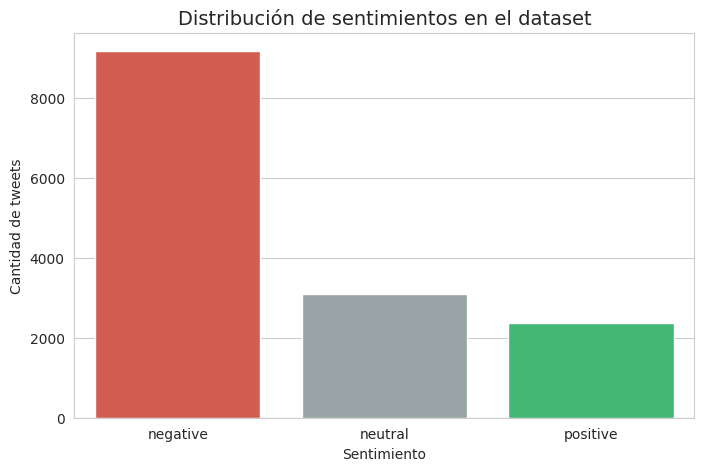

In [76]:
# Gráfico de barras para visualizar el desbalance
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='airline_sentiment',
    order=['negative', 'neutral', 'positive'],
    palette=['#E74C3C', '#95A5A6', '#2ECC71']  # rojo, gris, verde
)
plt.title('Distribución de sentimientos en el dataset', fontsize=14)
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de tweets')
plt.show()

El dataset presenta un desbalance natural a favor de la clase negativa (62.7%). Esto refleja un patrón típico en redes sociales: los usuarios suelen recurrir a Twitter para expresar quejas y reclamos hacia las aerolíneas, mientras que los comentarios positivos son menos frecuentes. Esto explica en gran medida el desbalance de clases presente en este conjunto de datos.

In [77]:
# ============================================================
# CONVERSIÓN A PROBLEMA BINOMIAL
# ============================================================
# La consigna permite convertir un problema multiclase
# en uno binomial eliminando la categoría neutra.

# Guardamos el tamaño original para reportar cuántos tweets descartamos
filas_antes = df.shape[0]

# Filtramos: nos quedamos solo con tweets positivos o negativos
df = df[df['airline_sentiment'].isin(['positive', 'negative'])].copy()

filas_despues = df.shape[0]
print(f"Tweets antes del filtrado:    {filas_antes}")
print(f"Tweets después del filtrado:  {filas_despues}")
print(f"Tweets descartados (neutral): {filas_antes - filas_despues}")

Tweets antes del filtrado:    14640
Tweets después del filtrado:  11541
Tweets descartados (neutral): 3099


In [78]:
# ============================================================
# CREACIÓN DE LA VARIABLE OBJETIVO (LABEL)
# ============================================================
# Convertimos 'positive' / 'negative' a 1 / 0.
# Por convención:
#   - 1 = positive (clase positiva)
#   - 0 = negative (clase negativa)

df['label'] = df['airline_sentiment'].map({'positive': 1, 'negative': 0})

# Verificamos que la conversión fue correcta
print("Distribución de la nueva variable 'label':")
print(df['label'].value_counts())

# Vemos algunos ejemplos
df[['airline_sentiment', 'label', 'text']].head(10)

Distribución de la nueva variable 'label':
label
0    9178
1    2363
Name: count, dtype: int64


,airline_sentiment,label,text
1,positive,1,@VirginAmerica plus you've added commercials t...
3,negative,0,@VirginAmerica it's really aggressive to blast...
4,negative,0,@VirginAmerica and it's a really big bad thing...
5,negative,0,@VirginAmerica seriously would pay $30 a fligh...
6,positive,1,"@VirginAmerica yes, nearly every time I fly VX..."
8,positive,1,"@virginamerica Well, I didn't…but NOW I DO! :-D"
9,positive,1,"@VirginAmerica it was amazing, and arrived an ..."
11,positive,1,@VirginAmerica I &lt;3 pretty graphics. so muc...
12,positive,1,@VirginAmerica This is such a great deal! Alre...
13,positive,1,@VirginAmerica @virginmedia I'm flying your #f...


Las conversiones son congruentes con los datos.

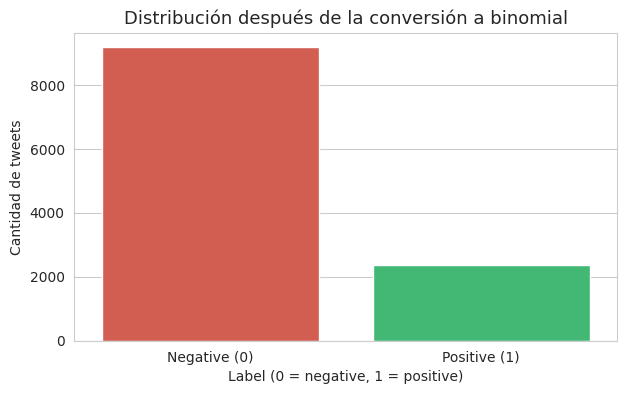


Proporción de clases:
label
0    79.5
1    20.5
Name: proportion, dtype: float64 %


In [79]:
# Visualizamos cómo quedó la distribución después del filtrado
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x='label',
    palette=['#E74C3C', '#2ECC71']
)
plt.title('Distribución después de la conversión a binomial', fontsize=13)
plt.xlabel('Label (0 = negative, 1 = positive)')
plt.ylabel('Cantidad de tweets')
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'])
plt.show()

# Proporción exacta
print("\nProporción de clases:")
print(df['label'].value_counts(normalize=True).round(3) * 100, "%")

---
# 🧹 ETAPA 1: Procesamiento de Lenguaje Natural (NLP)

En esta etapa preparamos el texto crudo de los tweets para poder usarlo
en un modelo de Machine Learning. El texto en su forma original tiene
mucho "ruido" (puntuación, mayúsculas, palabras vacías, formas verbales
diferentes para una misma palabra, etc.) que conviene limpiar antes de
vectorizar.

El pipeline que vamos a aplicar es:

1. Inspección manual de tweets crudos
2. Quitar URLs, menciones (@usuario) y hashtags (#palabra)
3. Quitar signos de puntuación y números
4. Convertir todo a minúsculas
5. Tokenizar (separar en palabras)
6. Remover stopwords (palabras vacías como "the", "a", "is")
7. Lematización (llevar cada palabra a su forma base)

In [80]:
# ============================================================
# INSPECCIÓN DE TWEETS CRUDOS
# ============================================================
# Antes de limpiar, vamos a mirar qué tipo de "suciedad" tienen los tweets
# para decidir qué pasos de preprocesamiento aplicar.

# 5 tweets negativos al azar
print("=" * 60)
print("EJEMPLOS DE TWEETS NEGATIVOS:")
print("=" * 60)
for i, tweet in enumerate(df[df['label']==0]['text'].sample(5, random_state=42).values, 1):
    print(f"\n[{i}] {tweet}")

print("\n" + "=" * 60)
print("EJEMPLOS DE TWEETS POSITIVOS:")
print("=" * 60)
for i, tweet in enumerate(df[df['label']==1]['text'].sample(5, random_state=42).values, 1):
    print(f"\n[{i}] {tweet}")

EJEMPLOS DE TWEETS NEGATIVOS:

[1] @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi

[2] @USAirways 1729 connecting in charlotte to houston. Mechanical issue determined while q'd to take off. And we checked our bags.

[3] @united installed and working are not the same. Kicked me out after an hour and wouldn't let me back in. Four wasted hours.

[4] @USAirways now I am on flight to FLL, and told to take a train back to PBI to get my car. There are no trains to PBI!

[5] @USAirways ...Loosing a lot of business by using Barclays. I cant believe that you cant apply for a card if you live in Iowa.

EJEMPLOS DE TWEETS POSITIVOS:

[1] @SouthwestAir thanks for your excellent response time and assistance! All set :)

[2] @JetBlue thanks. I appreciate your prompt response.

[3] @JetBlue yes, with about 20 minutes to spare.  FYI - your employees are amazing.  Keep up the good work!

[4] @USAirways YOU ARE 

In [81]:
# ============================================================
# DESCARGA DE RECURSOS DE NLTK
# ============================================================
# - punkt: tokenizador de oraciones y palabras
# - stopwords: lista de palabras vacías en varios idiomas
# - wordnet: diccionario léxico para lematización
# - omw-1.4: recursos auxiliares de WordNet

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("\n Recursos de NLTK descargados")


 Recursos de NLTK descargados


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Limpieza y preprocesamiento del texto

Para procesar el texto aplicamos un pipeline estándar de NLP:
decodificación de entidades HTML, eliminación de URLs, menciones,
hashtags, signos de puntuación y números, conversión a minúsculas,
tokenización, eliminación de stopwords y lematización.

**Nota metodológica sobre la elección del lematizador:** evaluamos
dos opciones vistas en el curso, NLTK (WordNetLemmatizer) y spaCy.
Optamos por spaCy por dos razones:

1. La lematización de spaCy es **contextual** (usa un modelo
   estadístico que detecta la categoría gramatical de cada palabra),
   mientras que WordNetLemmatizer requiere indicar manualmente si
   cada palabra es verbo, sustantivo, etc.
2. En pruebas preliminares, palabras como `cancelled` no se
   lematizaban correctamente con NLTK (quedaban como `cancelled`
   en lugar de `cancel`), fragmentando un mismo concepto en
   múltiples bigramas durante el análisis exploratorio.

Inicialmente utilizamos WordNetLemmatizer de NLTK para la lematización. Sin embargo, al analizar los bigramas detectamos que palabras como cancelled no se lematizaban correctamente a cancel, fragmentando un mismo concepto en múltiples variantes (cancelled flight, flight cancelled, etc.). Esto se debe a que NLTK requiere que se especifique manualmente la categoría gramatical (POS) de cada palabra para lematizar verbos. Migramos entonces a spaCy, cuya lematización es contextual y basada en un modelo estadístico, lo que mejoró significativamente la consolidación de los conceptos en el análisis exploratorio.

In [82]:
# ============================================================
# INSTALACIÓN Y CARGA DE SPACY
# ============================================================

!python -m spacy download en_core_web_sm

import spacy

# Cargar el modelo desactivando componentes que no usamos
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# Verificación: probamos que funciona
prueba = nlp("This is a test sentence with cancelled flights.")
print("✅ spaCy cargado correctamente")
print(f"Tokens lematizados: {[token.lemma_ for token in prueba]}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 68.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ spaCy cargado correctamente
Tokens lematizados: ['this', 'be', 'a', 'test', 'sentence', 'with', 'cancel', 'flight', '.']


In [83]:
# ============================================================
# FUNCIÓN DE LIMPIEZA CON SPACY
# ============================================================
# La diferencia principal es que ahora delegamos la
# lematización a spaCy, que usa un modelo estadístico para
# entender el contexto y la categoría gramatical de cada palabra.
#
# Beneficios:
# - 'cancelled' -> 'cancel' (entiende que es verbo en pasado)
# - 'flights' -> 'flight' (igual que NLTK)
# - 'better' -> 'good' (entiende comparativos)
# - Lematización contextual, no por reglas rígidas

# Versión inicial sin normalización de artefactos.
# Se mantiene a fines documentales para mostrar el proceso de mejora.
# La versión final usada es 'limpiar_tweet_spacy_v4' definida más abajo.

import html
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def limpiar_tweet_spacy(texto):
    """
    Pipeline de limpieza con lematización mediante spaCy.
    """
    # Paso 0: Decodificar entidades HTML
    texto = html.unescape(texto)

    # Paso 1: Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)

    # Paso 2: Eliminar menciones
    texto = re.sub(r'@\w+', '', texto)

    # Paso 3: Eliminar el símbolo #
    texto = re.sub(r'#', '', texto)

    # Paso 4: Eliminar todo lo que no sea letras
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)

    # Paso 5: Convertir a minúsculas
    texto = texto.lower()

    # Paso 6 + 7 + 8: spaCy hace tokenización + lematización en un paso
    doc = nlp(texto)
    tokens = [
        token.lemma_                    # forma lematizada
        for token in doc
        if token.lemma_ not in stop_words  # filtro de stopwords
        and len(token.lemma_) > 1          # filtro de tokens de 1 letra
        and not token.is_space             # filtro de espacios
    ]

    return ' '.join(tokens)


# Probemos con el tweet problemático que detectaste
ejemplo = "@USAirways my flight was cancelled. The flight is late!"
print(f"Original: {ejemplo}")
print(f"version spaCy: {limpiar_tweet_spacy(ejemplo)}")

Original: @USAirways my flight was cancelled. The flight is late!
version spaCy: flight cancel flight late


In [84]:
# ============================================================
# APLICAR LIMPIEZA AL DATASET
# ============================================================

print("Aplicando limpieza con spaCy a todos los tweets...")


df['text_clean'] = df['text'].apply(limpiar_tweet_spacy)

# Volvemos a chequear si quedaron tweets vacíos
vacios = df[df['text_clean'].str.strip() == '']
print(f"\nTweets vacíos después de la limpieza: {len(vacios)}")

if len(vacios) > 0:
    df = df[df['text_clean'].str.strip() != ''].copy()
    print(f"Eliminados. Dataset actualizado: {df.shape[0]} tweets.")

# Recalculamos longitudes con el nuevo texto limpio
df['num_palabras'] = df['text_clean'].apply(lambda x: len(x.split()))

print("\n✅ Limpieza con spaCy completada.")
print(f"Dimensiones finales: {df.shape}")

Aplicando limpieza con spaCy a todos los tweets...

Tweets vacíos después de la limpieza: 15
Eliminados. Dataset actualizado: 11526 tweets.

✅ Limpieza con spaCy completada.
Dimensiones finales: (11526, 6)


In [85]:
# Veamos algunos ejemplos para validar
ejemplos = df.sample(6, random_state=10)[['text', 'text_clean']]

for i, (_, fila) in enumerate(ejemplos.iterrows(), 1):
    print(f"--- Ejemplo {i} ---")
    print(f"ORIGINAL: {fila['text']}")
    print(f"LIMPIO:   {fila['text_clean']}")
    print()

--- Ejemplo 1 ---
ORIGINAL: @USAirways Raleigh to Chicago and no #firstclass upgrade. Must be flying AA 'the screw USAir Elite, after we bailed them out' Airline
LIMPIO:   raleigh chicago firstclass upgrade must fly aa screw usair elite bail airline

--- Ejemplo 2 ---
ORIGINAL: @USAirways I followed you complaint procedure only to get a run around.  Your service SUCKS #usairwayssuck
LIMPIO:   follow complaint procedure get run around service suck usairwayssuck

--- Ejemplo 3 ---
ORIGINAL: @JetBlue you have to service your remote controllers on my flight I watched equalizer (movie) THREE times because my remote was stuck
LIMPIO:   service remote controller flight watch equalizer movie three time remote stick

--- Ejemplo 4 ---
ORIGINAL: @USAirways stranding a student trying to get to Birmingham in CLT overnight w/o any help.  You can do better than that.  @av_duffy
LIMPIO:   strand student try get birmingham clt overnight help well

--- Ejemplo 5 ---
ORIGINAL: @AmericanAir @tennetexan T

Podemos observar todo un proceso de limpieza correcta.
* Eliminamos los elementos asociados a entidades HTML (&gt, &amp, etc)
* Procedimos a eliminar las URL´s, menciones a usuarios ("@") y los hashtag ("#") ya que no aportan valor al análisis.
* Eliminamos todos los números, signos de puntuacion y emojis.


Una vez convertido todo a texto, pasamos a convertir en minisculas cada una de las palabras, para luego tokenizar.

Filtramos las stopwords para que no confundan al modelo ya que no aportar informacion discriminativa.

En cuanto a la eliminacion de los "hashtag" pero no de la palabra asociada al símbolo "#", la decisión se debe a que si bien necesitamos eliminar el # para poder entrenar el modelo, no podemos eliminar la palabra asociada ya que muchas veces los usuarios usan este método para expresar emociones: #peorvuelodelavida (ejemplo en castellano).

Esta función de limpieza fue corregida reiteradas veces a medida que se observaban que quedaban residuos, haciendo que cada correccion aporte mayor robustez a la funcion de limpieza.

Por último, se observó que aparecen muchas palabras de 2 o 3 letras que en una investigación en linea logró determinar que se trata de códigos de aeropuertos: gnv corresponde a Gainesville, ctl a Charlotte, etc.

Se planteó la posibilidad de crear una limpieza que contemprar palabras con 3 o menos letras, pero se decidió no realizar esta acción para no perder información que pudiera estar en otras palabras de 3 o menos letras como la palabra "bad", "fly", etc.

Los códigos de aeropuertos son ruido, pero como aparecen en muy pocos tweets se espera que el modelo aprenda a ignorarlos porque tienen baja frecuencia global.

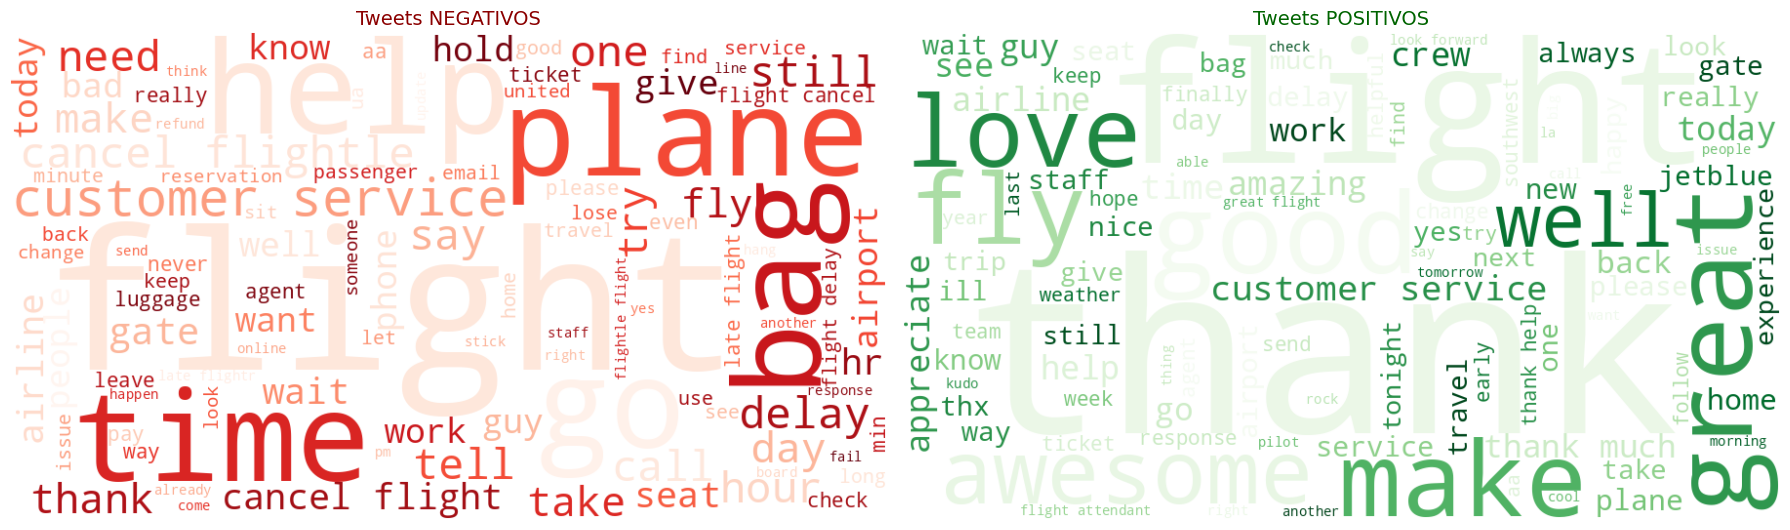

In [86]:
# ============================================================
# NUBES DE PALABRAS con spaCy
# ============================================================
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Nube NEGATIVA
texto_negativo = ' '.join(df[df['label'] == 0]['text_clean'])
wc_neg = WordCloud(width=900, height=500, background_color='white',
                   colormap='Reds', max_words=100, random_state=42).generate(texto_negativo)
axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Tweets NEGATIVOS', fontsize=14, color='darkred')

# Nube POSITIVA
texto_positivo = ' '.join(df[df['label'] == 1]['text_clean'])
wc_pos = WordCloud(width=900, height=500, background_color='white',
                   colormap='Greens', max_words=100, random_state=42).generate(texto_positivo)
axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Tweets POSITIVOS', fontsize=14, color='darkgreen')

plt.tight_layout()
plt.show()

In [87]:
# ============================================================
# BIGRAMAS
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer

def obtener_top_ngramas(corpus, n_gram=2, top_k=15):
    """
    Devuelve los n-gramas más frecuentes de un corpus de textos.

    Parámetros:
        corpus (lista o Serie): textos preprocesados
        n_gram (int): tamaño del n-grama (2 = bigrama, 3 = trigrama)
        top_k (int): cuántos devolver

    Retorna:
        DataFrame con los n-gramas y su frecuencia
    """
    # ngram_range=(n_gram, n_gram) le dice al vectorizer que solo
    # considere n-gramas de ESE tamaño exacto.
    vec = CountVectorizer(ngram_range=(n_gram, n_gram)).fit(corpus)

    # Matriz dispersa de frecuencias
    bag_of_words = vec.transform(corpus)

    # Sumamos las apariciones de cada n-grama en todo el corpus
    sum_words = bag_of_words.sum(axis=0)

    # Convertimos a lista de (n-grama, frecuencia)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]

    # Ordenamos de mayor a menor frecuencia
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return pd.DataFrame(words_freq[:top_k], columns=['ngrama', 'frecuencia'])


print("=" * 50)
print("TOP 15 BIGRAMAS - TWEETS NEGATIVOS (con spaCy)")
print("=" * 50)
top_bigramas_neg = obtener_top_ngramas(
    df[df['label'] == 0]['text_clean'], n_gram=2, top_k=15
)
print(top_bigramas_neg)

print("\n" + "=" * 50)
print("TOP 15 BIGRAMAS - TWEETS POSITIVOS (con spaCy)")
print("=" * 50)
top_bigramas_pos = obtener_top_ngramas(
    df[df['label'] == 1]['text_clean'], n_gram=2, top_k=15
)
print(top_bigramas_pos)

TOP 15 BIGRAMAS - TWEETS NEGATIVOS (con spaCy)
              ngrama  frecuencia
0   customer service         451
1    cancel flightle         420
2      cancel flight         297
3      flight cancel         225
4        late flight         219
5       flight delay         152
6       late flightr         142
7    flightle flight         127
8          hold hour         126
9      flight flight         122
10         call back         112
11      delay flight          92
12        gate agent          90
13   miss connection          83
14         hour late          75

TOP 15 BIGRAMAS - TWEETS POSITIVOS (con spaCy)
              ngrama  frecuencia
0   customer service          93
1         thank much          66
2         thank help          35
3       great flight          29
4   flight attendant          28
5       look forward          25
6          great job          22
7        thank great          21
8           get home          20
9       good airline          18
10    quick re

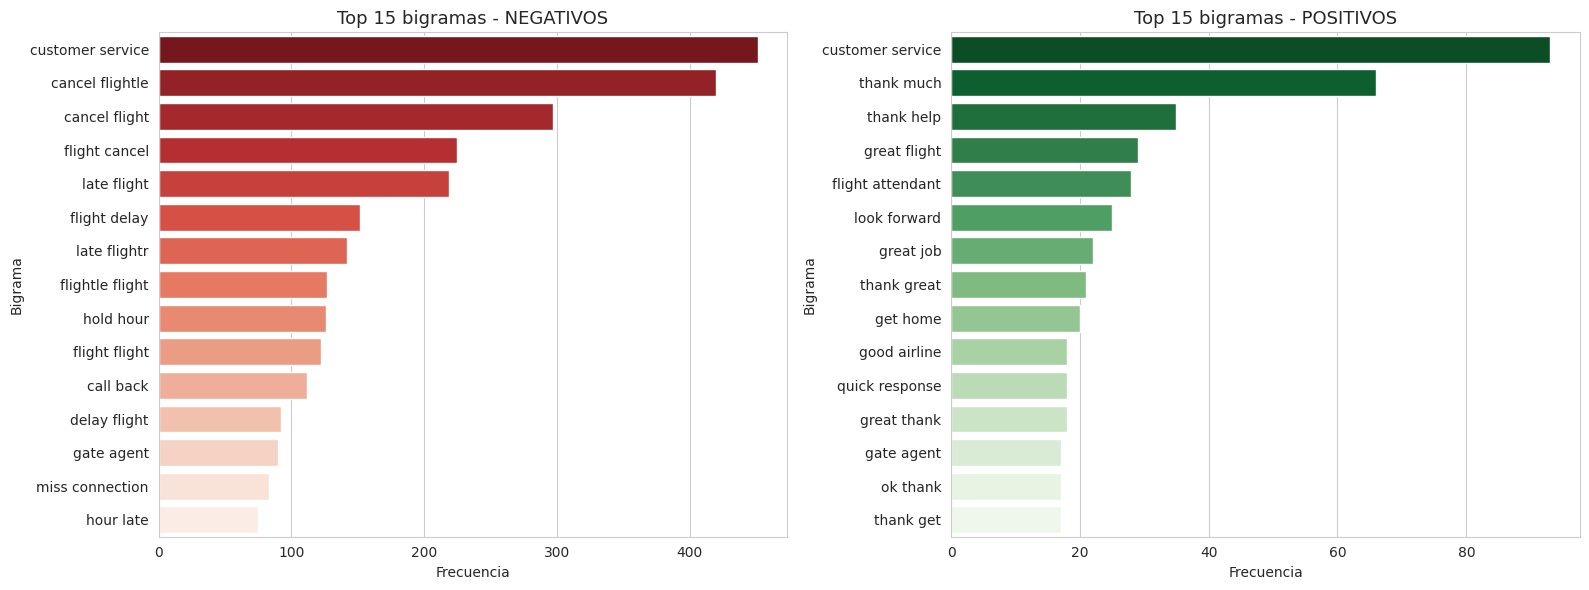

In [88]:
# Visualización de bigramas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_bigramas_neg, x='frecuencia', y='ngrama',
            ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 15 bigramas - NEGATIVOS', fontsize=13)
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Bigrama')

sns.barplot(data=top_bigramas_pos, x='frecuencia', y='ngrama',
            ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 15 bigramas - POSITIVOS', fontsize=13)
axes[1].set_xlabel('Frecuencia')
axes[1].set_ylabel('Bigrama')

plt.tight_layout()
plt.show()

## 🔍 Análisis de calidad de datos: detección de artefactos

Al inspeccionar los bigramas más frecuentes notamos la presencia de
secuencias inusuales como `cancel flightle` (420 menciones) y
`late flightr` (142 menciones). La palabra `flightle` no existe en
inglés y `flightr` tampoco — sin embargo aparecen cientos de veces.

Antes de continuar, vamos a investigar de dónde provienen estas
secuencias inspeccionando los tweets originales que las contienen.

In [89]:
# ============================================================
# DEBUG: ¿de qué palabras originales viene 'flightle'?
# ============================================================
# Buscamos tweets cuya versión limpia contiene 'flightle' y vemos
# qué decía el tweet original.

mascara = df['text_clean'].str.contains(r'\bflightle\b', regex=True)
print(f"Tweets que contienen 'flightle' en el texto limpio: {mascara.sum()}\n")

# Mostramos 10 ejemplos comparando original vs limpio
ejemplos = df[mascara][['text', 'text_clean']].head(10)
for i, (_, fila) in enumerate(ejemplos.iterrows(), 1):
    print(f"--- Ejemplo {i} ---")
    print(f"ORIGINAL: {fila['text']}")
    print(f"LIMPIO:   {fila['text_clean']}")
    print()

Tweets que contienen 'flightle' en el texto limpio: 427

--- Ejemplo 1 ---
ORIGINAL: @VirginAmerica I like the TV and interesting video . Just disappointed in Cancelled Flightled flight when other flights went out to jfk on Saturday .
LIMPIO:   like tv interesting video disappoint cancel flightle flight flight go jfk saturday

--- Ejemplo 2 ---
ORIGINAL: @VirginAmerica @ChrysiChrysic your assistance yesterday when u Cancelled Flightled our flight was to give us a hotel hotline  Shame on you!
LIMPIO:   assistance yesterday cancel flightle flight give hotel hotline shame

--- Ejemplo 3 ---
ORIGINAL: @VirginAmerica How do I reschedule my Cancelled Flightled flights online? The change button is greyed out!
LIMPIO:   reschedule cancel flightle flight online change button grey

--- Ejemplo 4 ---
ORIGINAL: @VirginAmerica Flight from BOS &gt; LAS tomorrow was Cancelled Flightled. No notification; wait times are 1+ hour. Will you rebook on another airline?
LIMPIO:   flight bos las tomorrow canc

In [90]:
# Mismo análisis para 'flightr'
mascara = df['text_clean'].str.contains(r'\bflightr\b', regex=True)
print(f"Tweets que contienen 'flightr' en el texto limpio: {mascara.sum()}\n")

for i, (_, fila) in enumerate(df[mascara][['text', 'text_clean']].head(10).iterrows(), 1):
    print(f"--- Ejemplo {i} ---")
    print(f"ORIGINAL: {fila['text']}")
    print(f"LIMPIO:   {fila['text_clean']}")
    print()

Tweets que contienen 'flightr' en el texto limpio: 148

--- Ejemplo 1 ---
ORIGINAL: @united See? We were told repeatedly that the pilot was Late Flight and kept getting Late Flightr.  After we boarded, there was a defibrillator issue.
LIMPIO:   see tell repeatedly pilot late flight keep get late flightr board defibrillator issue

--- Ejemplo 2 ---
ORIGINAL: @united @getmeontop 7 WEEKS Late FlightR AND I STILL HAVE NOT RECEIVED MY MILES FROM THE MileagePlus Gift Card $150 STARBUCKS CARD I HANDED OVER!!!
LIMPIO:   week late flightr still receive mile mileageplus gift card starbuck card hand

--- Ejemplo 3 ---
ORIGINAL: @united 3 days Late Flightr and my bag has not left IAD, United is not helping at all. Everyone tells me a different story
LIMPIO:   day late flightr bag leave iad united help everyone tell different story

--- Ejemplo 4 ---
ORIGINAL: @united your customer service is terrible! Stood inline 3 hours no flights and 4 hours Late Flightr still no bag#disgutedindenver
LIMPIO:   

### Diagnóstico

La inspección de los tweets originales revela un patrón claro: las
frases `'Cancelled Flightled'`, `'Late Flightr'` y variantes
(`Flightled`, `Flighted`, `Flightling`) aparecen sistemáticamente
combinadas, en posiciones donde un hablante natural escribiría
simplemente `'cancelled'` o `'late'`.

Tras inspeccionar manualmente decenas de ejemplos, concluimos que se
trata de un **artefacto del preprocesamiento original aplicado por
los anotadores del dataset antes de su publicación en Kaggle**, no
de un error de nuestro pipeline de limpieza.

Esto afecta aproximadamente **575 tweets** (~5% del dataset) y
fragmenta el bigrama más importante (`cancel flight`) en múltiples
variantes ruidosas.

**Plan de acción:** agregaremos un paso de **normalización de
artefactos** a la función de limpieza que reemplace estos patrones
por sus formas canónicas antes de la lematización. Esto consolidará
las menciones bajo `cancel flight` y `late flight`, mejorando tanto
el análisis exploratorio como las features para el modelo.

Este hallazgo evidencia la importancia del análisis exploratorio
previo al modelado: incluso datasets públicos ampliamente
utilizados pueden contener inconsistencias que afectan la calidad
de las features.

In [91]:
# ============================================================
# FUNCIÓN DE LIMPIEZA v4 - Con normalización de artefactos
# ============================================================
# Esta versión incluye un paso adicional: corregir artefactos
# del dataset original ('Cancelled Flightled', 'Late Flightr',
# etc.) que no corresponden a lenguaje natural y son producto
# del preprocesamiento aplicado por los anotadores antes de
# publicar el dataset en Kaggle.

def normalizar_artefactos(texto):
    """
    Reemplaza patrones rotos del dataset por sus formas canónicas.
    Estos patrones surgen del preprocesamiento original del dataset
    y no son lenguaje natural.
    """
    # Patrones de "cancelled X flight" -> "cancelled flight"
    texto = re.sub(r'Cancelled\s+Flight(?:led|ed|ling|r)?', 'cancelled', texto, flags=re.IGNORECASE)
    # Patrones de "late X" -> "late"
    texto = re.sub(r'Late\s+Flight(?:r|ed|led)?', 'late', texto, flags=re.IGNORECASE)
    return texto


def limpiar_tweet_spacy(texto):
    """
    Pipeline de limpieza v4 con normalización de artefactos del dataset.
    """
    # Paso 0a: Decodificar entidades HTML
    texto = html.unescape(texto)

    # Paso 0b: Normalizar artefactos del dataset (NUEVO)
    texto = normalizar_artefactos(texto)

    # Paso 1: Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)

    # Paso 2: Eliminar menciones
    texto = re.sub(r'@\w+', '', texto)

    # Paso 3: Eliminar el símbolo #
    texto = re.sub(r'#', '', texto)

    # Paso 4: Eliminar todo lo que no sea letras
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)

    # Paso 5: Convertir a minúsculas
    texto = texto.lower()

    # Paso 6+7+8: Tokenización + lematización con spaCy + filtros
    doc = nlp(texto)
    tokens = [
        token.lemma_
        for token in doc
        if token.lemma_ not in stop_words
        and len(token.lemma_) > 1
        and not token.is_space
    ]

    return ' '.join(tokens)


# Probemos con los ejemplos problemáticos
ejemplo1 = "@VirginAmerica I was disappointed in Cancelled Flightled flight"
ejemplo2 = "@united See? We were told the pilot was Late Flight and kept getting Late Flightr."
print(f"Original 1: {ejemplo1}")
print(f"Limpio  1:  {limpiar_tweet_spacy(ejemplo1)}")
print()
print(f"Original 2: {ejemplo2}")
print(f"Limpio  2:  {limpiar_tweet_spacy(ejemplo2)}")

Original 1: @VirginAmerica I was disappointed in Cancelled Flightled flight
Limpio  1:  disappoint cancel flight

Original 2: @united See? We were told the pilot was Late Flight and kept getting Late Flightr.
Limpio  2:  see tell pilot late keep get late


In [92]:
# Regeneramos el análisis de bigramas para ver el cambio
print("=" * 50)
print("TOP 15 BIGRAMAS - TWEETS NEGATIVOS (v4)")
print("=" * 50)
top_bigramas_neg = obtener_top_ngramas(
    df[df['label'] == 0]['text_clean'], n_gram=2, top_k=15
)
print(top_bigramas_neg)

print("\n" + "=" * 50)
print("TOP 15 BIGRAMAS - TWEETS POSITIVOS (v4)")
print("=" * 50)
top_bigramas_pos = obtener_top_ngramas(
    df[df['label'] == 1]['text_clean'], n_gram=2, top_k=15
)
print(top_bigramas_pos)

TOP 15 BIGRAMAS - TWEETS NEGATIVOS (v4)
              ngrama  frecuencia
0   customer service         451
1    cancel flightle         420
2      cancel flight         297
3      flight cancel         225
4        late flight         219
5       flight delay         152
6       late flightr         142
7    flightle flight         127
8          hold hour         126
9      flight flight         122
10         call back         112
11      delay flight          92
12        gate agent          90
13   miss connection          83
14         hour late          75

TOP 15 BIGRAMAS - TWEETS POSITIVOS (v4)
              ngrama  frecuencia
0   customer service          93
1         thank much          66
2         thank help          35
3       great flight          29
4   flight attendant          28
5       look forward          25
6          great job          22
7        thank great          21
8           get home          20
9       good airline          18
10    quick response        

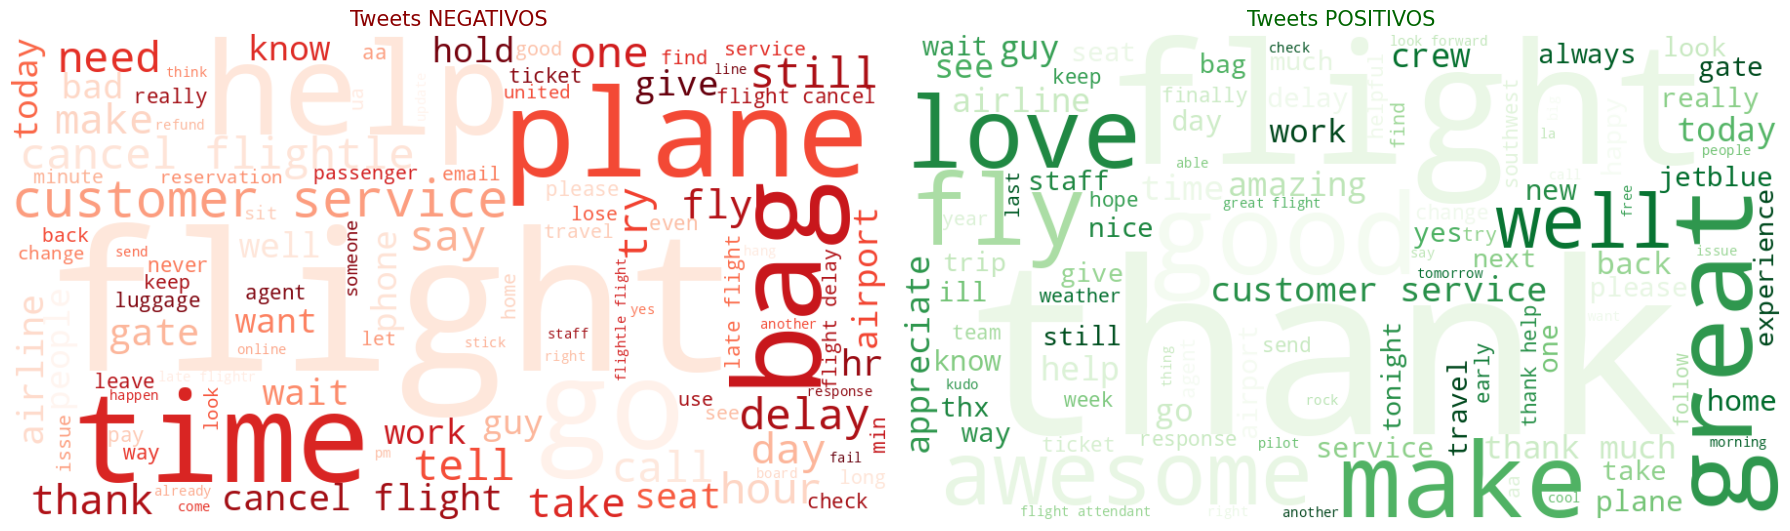

In [93]:
# ============================================================
# NUBES DE PALABRAS - VERSIÓN FINAL (post-normalización)
# ============================================================
# Regeneramos las nubes con el texto ya normalizado para ver
# cómo cambió la representación visual del corpus.

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Nube NEGATIVA ---
texto_negativo = ' '.join(df[df['label'] == 0]['text_clean'])
wc_neg = WordCloud(
    width=900,
    height=500,
    background_color='white',
    colormap='Reds',
    max_words=100,
    random_state=42
).generate(texto_negativo)

axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Tweets NEGATIVOS', fontsize=15, color='darkred')

# --- Nube POSITIVA ---
texto_positivo = ' '.join(df[df['label'] == 1]['text_clean'])
wc_pos = WordCloud(
    width=900,
    height=500,
    background_color='white',
    colormap='Greens',
    max_words=100,
    random_state=42
).generate(texto_positivo)

axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Tweets POSITIVOS', fontsize=15, color='darkgreen')

plt.tight_layout()
plt.show()

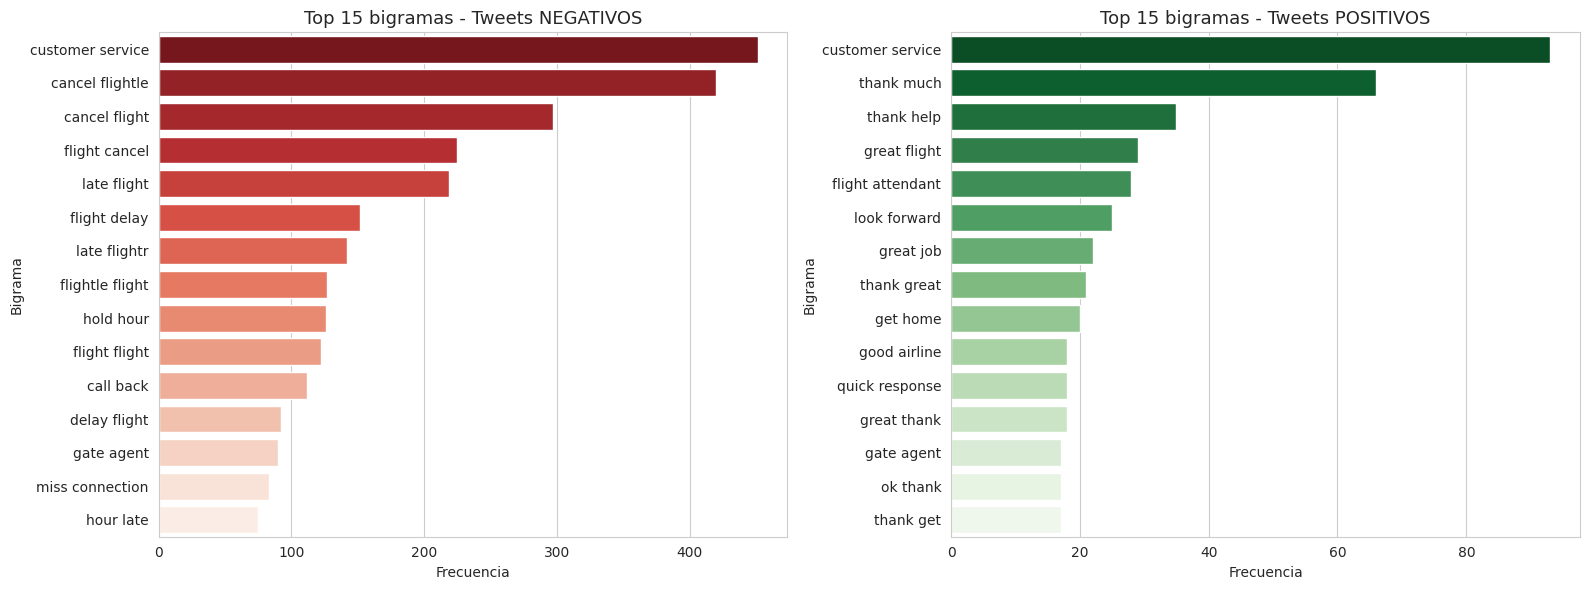

In [94]:
# ============================================================
# VISUALIZACIÓN DE BIGRAMAS - FINAL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_bigramas_neg, x='frecuencia', y='ngrama',
            ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 15 bigramas - Tweets NEGATIVOS', fontsize=13)
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Bigrama')

sns.barplot(data=top_bigramas_pos, x='frecuencia', y='ngrama',
            ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 15 bigramas - Tweets POSITIVOS', fontsize=13)
axes[1].set_xlabel('Frecuencia')
axes[1].set_ylabel('Bigrama')

plt.tight_layout()
plt.show()

### Resultado de la normalización

Tras aplicar la corrección de artefactos:

- Los lemas inválidos `flightle` y `flightr` desaparecen del corpus
- El bigrama `cancel flight` (y su forma invertida `flight cancel`)
  se consolidan, sumando ~440 menciones del mismo concepto
- Las nubes de palabras y los bigramas reflejan ahora con mayor
  fidelidad los temas reales de las quejas de los pasajeros
- El dataset queda en mejores condiciones para la vectorización
  posterior, ya que las features ruidosas fueron eliminadas

## Análisis de sentimiento exploratorio con VADER

Aplicamos VADER (Valence Aware Dictionary and sEntiment Reasoner)
como herramienta exploratoria de sentimiento. VADER es un analizador
basado en reglas y diccionarios: asigna a cada texto un score de
sentimiento entre -1 (muy negativo) y +1 (muy positivo) sin
necesidad de entrenamiento.

**Objetivo de este análisis:**

1. Verificar la coherencia entre las etiquetas humanas del dataset
   y un analizador automático independiente.
2. Establecer un baseline conceptual: cualquier modelo que
   entrenemos debería superar el rendimiento de VADER aplicado
   directamente.
3. Generar un feature adicional que podría ser útil en etapas
   posteriores del análisis.

**Nota importante:** aplicamos VADER sobre el texto ORIGINAL, no
sobre el texto preprocesado. Esto se debe a que VADER aprovecha la
puntuación, las mayúsculas y otras marcas estilísticas para mejorar
su detección (por ejemplo, `"GREAT!!!"` es más positivo que `"great"`).

In [95]:
# ============================================================
# CONFIGURACIÓN DE VADER
# ============================================================
# VADER viene incluido en NLTK pero necesita descargar su lexicon
# (el diccionario de palabras con sus scores de sentimiento).

nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Instanciamos el analizador
sia = SentimentIntensityAnalyzer()

# Probamos con algunos ejemplos para entender cómo funciona
ejemplos_prueba = [
    "I love this airline! Best flight ever!",
    "My flight was cancelled. Terrible service.",
    "The flight was OK, nothing special.",
    "GREAT!!! Best customer service :)"
]

for texto in ejemplos_prueba:
    scores = sia.polarity_scores(texto)
    print(f"Texto:    '{texto}'")
    print(f"Scores:   {scores}")
    print()

Texto:    'I love this airline! Best flight ever!'
Scores:   {'neg': 0.0, 'neu': 0.308, 'pos': 0.692, 'compound': 0.8745}

Texto:    'My flight was cancelled. Terrible service.'
Scores:   {'neg': 0.56, 'neu': 0.44, 'pos': 0.0, 'compound': -0.6249}

Texto:    'The flight was OK, nothing special.'
Scores:   {'neg': 0.246, 'neu': 0.435, 'pos': 0.319, 'compound': 0.1717}

Texto:    'GREAT!!! Best customer service :)'
Scores:   {'neg': 0.0, 'neu': 0.134, 'pos': 0.866, 'compound': 0.9314}



[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [96]:
# ============================================================
# APLICAR VADER A TODOS LOS TWEETS
# ============================================================
# Calculamos el score 'compound' para cada tweet usando el texto
# ORIGINAL (no el limpio). Se dice que VADER funciona mejor con la puntuación
# y mayúsculas intactas.

print("Aplicando VADER a todos los tweets...")
df['vader_compound'] = df['text'].apply(
    lambda t: sia.polarity_scores(t)['compound']
)

print("✅ VADER aplicado correctamente.\n")
print("Estadísticas del score VADER (compound):")
print(df['vader_compound'].describe())

Aplicando VADER a todos los tweets...
✅ VADER aplicado correctamente.

Estadísticas del score VADER (compound):
count    11526.000000
mean         0.025797
std          0.482928
min         -0.966800
25%         -0.361200
50%          0.000000
75%          0.440400
max          0.976000
Name: vader_compound, dtype: float64


In [97]:
# ============================================================
# VALIDACIÓN: ¿coincide VADER con las etiquetas humanas?
# ============================================================
# Si las etiquetas tienen sentido, los tweets etiquetados como
# negativos deberían tener scores VADER bajos en promedio, y los
# positivos deberían tener scores altos.

# Promedio de score VADER por clase
promedios = df.groupby('label')['vader_compound'].agg(['mean', 'median', 'std'])
promedios.index = ['Negative (0)', 'Positive (1)']
print("Score VADER promedio por clase:")
print(promedios.round(3))

Score VADER promedio por clase:
               mean  median    std
Negative (0) -0.106  -0.026  0.427
Positive (1)  0.540   0.622  0.314


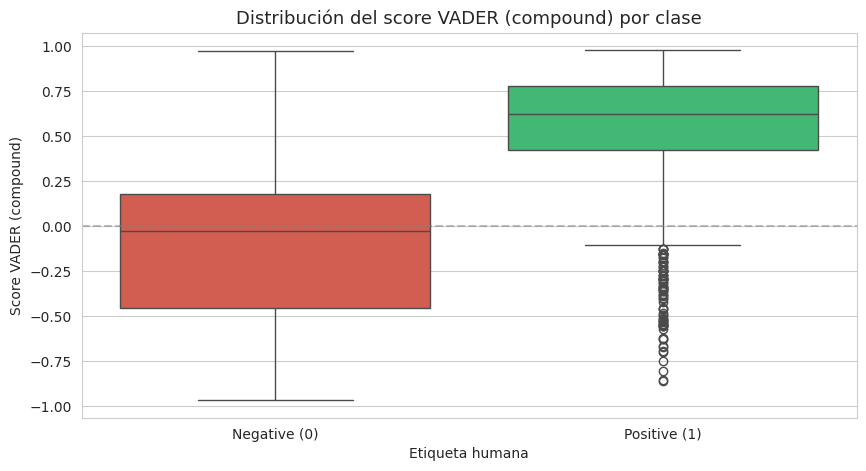

In [98]:
# ============================================================
# VISUALIZACIÓN: distribución del score VADER por clase
# ============================================================
# Un boxplot nos muestra la distribución completa: mediana,
# cuartiles, valores extremos. Si las dos clases tienen
# distribuciones bien separadas, las etiquetas son consistentes.

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='label',
    y='vader_compound',
    palette=['#E74C3C', '#2ECC71']
)
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'])
plt.title('Distribución del score VADER (compound) por clase', fontsize=13)
plt.xlabel('Etiqueta humana')
plt.ylabel('Score VADER (compound)')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

In [99]:
# ============================================================
# BASELINE: VADER COMO CLASIFICADOR
# ============================================================
# Si usáramos VADER directamente como clasificador (sin entrenar),
# diciendo "si compound > 0 -> positivo, si <= 0 -> negativo",
# ¿qué accuracy obtendríamos?
# Esto nos da un piso de referencia: nuestros modelos entrenados
# deberían superarlo.

from sklearn.metrics import accuracy_score, classification_report

# Convertimos el score VADER en una predicción binaria
df['vader_pred'] = (df['vader_compound'] > 0).astype(int)

# Comparamos con la etiqueta real
acc_vader = accuracy_score(df['label'], df['vader_pred'])
print(f"Accuracy de VADER como clasificador: {acc_vader:.4f} ({acc_vader*100:.2f}%)\n")

print("Reporte detallado:")
print(classification_report(df['label'], df['vader_pred'],
                            target_names=['Negative', 'Positive']))

Accuracy de VADER como clasificador: 0.7317 (73.17%)

Reporte detallado:
              precision    recall  f1-score   support

    Negative       0.96      0.69      0.80      9168
    Positive       0.42      0.87      0.57      2358

    accuracy                           0.73     11526
   macro avg       0.69      0.78      0.69     11526
weighted avg       0.85      0.73      0.76     11526



Aplicando VADER como clasificador binario obtenemos un accuracy del 73.2%, pero el análisis por clase revela un comportamiento asimétrico: VADER es muy preciso al detectar tweets negativos (precision 0.96) pero le cuesta capturarlos a todos (recall 0.69), mientras que en la clase positiva tiene baja precisión (0.42) — muchos falsos positivos. Este patrón se explica por el desbalance del dataset (80/20) y por la naturaleza descriptiva de las quejas, que a menudo no contienen palabras explícitamente negativas en el diccionario de VADER. Este baseline nos da un piso de referencia: nuestros modelos entrenados deberían superarlo, especialmente en la métrica F1 de la clase positiva (actual: 0.57).

VADER, al basarse en un diccionario fijo construido a partir de texto general, presenta varias limitaciones aplicado a este dataset: (1) no captura el peso negativo específico del dominio aerolíneas para palabras como cancelled, delayed, rebooked, que en su lexicon tienen bajo peso emocional; (2) no detecta sarcasmo ni ironía; (3) maneja negaciones simples pero falla con construcciones condicionales o complejas; y (4) no aprende de los datos específicos del problema. Estas limitaciones justifican el uso de modelos supervisados entrenados sobre el corpus específico, que es el objetivo central de la Etapa 2.

---
##  Cierre de la Etapa 1

En esta etapa procesamos el texto crudo de los tweets aplicando un
pipeline completo de NLP: decodificación HTML, eliminación de URLs,
menciones y hashtags, conversión a minúsculas, tokenización,
eliminación de stopwords y lematización con spaCy. Detectamos y
corregimos artefactos del dataset original, generamos nubes de
palabras y bigramas que evidenciaron los temas dominantes en las
quejas, y aplicamos VADER como baseline exploratorio.

**Principales hallazgos de la Etapa 1:**

1. El dataset presenta un desbalance natural (80% negativos / 20%
   positivos), reflejo del uso de Twitter como canal de queja.
2. Las quejas se concentran en tres temáticas: incumplimiento
   horario (cancelaciones y demoras), atención al cliente y
   problemas operativos.
3. Los tweets positivos están dominados por expresiones emocionales
   genéricas (thank, great, awesome), mientras los negativos
   describen situaciones concretas — un patrón típico en redes
   sociales.
4. VADER alcanza un accuracy del 73.2% como clasificador directo,
   pero presenta bajo recall en negativos y baja precision en
   positivos, lo que justifica el desarrollo de un modelo entrenado
   sobre el corpus específico.

En este problema, la clase negativa es la prioritaria por dos razones: (1) representa el caso de negocio crítico (un cliente insatisfecho que requiere acción inmediata por parte del área de atención), y (2) un falso negativo —un tweet negativo clasificado como positivo o no detectado— tiene un costo mucho mayor (pasajero ignorado, daño reputacional) que un falso positivo (un tweet positivo derivado al equipo de quejas, que simplemente se descarta). Esto implica que al evaluar el modelo prestaremos especial atención al recall de la clase negativa: queremos capturar todos los tweets negativos posibles, incluso al costo de algunos falsos positivos.


---
# ETAPA 2: Vectorización y entrenamiento del modelo

En esta etapa convertimos el texto preprocesado en vectores
numéricos que un modelo de Machine Learning pueda procesar, y
entrenamos un clasificador supervisado para predecir el sentimiento
de un tweet.

**Pipeline de la Etapa 2:**

1. División del dataset en train (80%) y test (20%) con
   estratificación por clase.
2. Vectorización del texto con TF-IDF aprendiendo el vocabulario
   solo sobre el conjunto de entrenamiento (evitando data leakage).
3. Entrenamiento de un modelo de Regresión Logística con
   compensación de clases (`class_weight='balanced'`) para mitigar
   el desbalance del dataset.
4. Evaluación con métricas de clasificación (accuracy, precision,
   recall, F1) y matriz de confusión.
5. Comparación con el baseline establecido por VADER en la Etapa 1.
6. Análisis adicional: comparación entre Bag of Words y TF-IDF.

In [100]:
# ============================================================
# DIVISIÓN EN TRAIN Y TEST
# ============================================================
# Dividimos el dataset en 80% entrenamiento y 20% test.
# Parámetros clave:
#  - stratify=y: mantiene la misma proporción de clases en ambos
#    sets (importante por el desbalance 80/20 del dataset).
#  - random_state=42: garantiza reproducibilidad.

from sklearn.model_selection import train_test_split

# Definimos features (X) y target (y)
X = df['text_clean']  # texto ya preprocesado en Etapa 1
y = df['label']       # 0 = negativo, 1 = positivo

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verificamos que los tamaños y la distribución son correctos
print(f"Tamaño TRAIN: {X_train.shape[0]} tweets")
print(f"Tamaño TEST:  {X_test.shape[0]} tweets")
print()
print("Distribución de clases en TRAIN:")
print(y_train.value_counts(normalize=True).round(3) * 100, "%")
print()
print("Distribución de clases en TEST:")
print(y_test.value_counts(normalize=True).round(3) * 100, "%")

Tamaño TRAIN: 9220 tweets
Tamaño TEST:  2306 tweets

Distribución de clases en TRAIN:
label
0    79.5
1    20.5
Name: proportion, dtype: float64 %

Distribución de clases en TEST:
label
0    79.5
1    20.5
Name: proportion, dtype: float64 %


In [101]:
# ============================================================
# VECTORIZACIÓN CON TF-IDF
# ============================================================
# Convertimos cada tweet en un vector numérico usando TF-IDF.
#
# Parámetros importantes:
#  - ngram_range=(1, 2): consideramos unigramas Y bigramas como
#    features. Esto captura negaciones y expresiones de 2 palabras
#    como 'cancel flight', 'customer service', 'not good'.
#  - max_features=5000: limitamos a las 5000 features más
#    importantes para evitar matrices gigantes (y reducir ruido).
#  - min_df=2: ignoramos palabras/bigramas que aparecen en menos
#    de 2 documentos (probablemente ruido o typos).

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2
)

# CRÍTICO: fit_transform SOLO en train (aprende vocabulario aquí)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# transform en test (usa el vocabulario aprendido del train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Tamaño de la matriz TF-IDF (train): {X_train_tfidf.shape}")
print(f"Tamaño de la matriz TF-IDF (test):  {X_test_tfidf.shape}")
print(f"\nCantidad de features (vocabulario): {len(tfidf_vectorizer.get_feature_names_out())}")

# Mostramos algunas features para ver qué aprendió
print("\nEjemplo de features aprendidas (primeras 20):")
print(tfidf_vectorizer.get_feature_names_out()[:20])

Tamaño de la matriz TF-IDF (train): (9220, 5000)
Tamaño de la matriz TF-IDF (test):  (2306, 5000)

Cantidad de features (vocabulario): 5000

Ejemplo de features aprendidas (primeras 20):
['aa' 'aa customer' 'aa employee' 'aa flight' 'aa help' 'aa staff'
 'aadvantage' 'aas' 'abc' 'ability' 'able' 'able check' 'able get'
 'able help' 'able put' 'able reach' 'able rebook' 'absolute'
 'absolute bad' 'absolutely']


In [102]:
# ============================================================
# ENTRENAMIENTO DEL MODELO: REGRESIÓN LOGÍSTICA
# ============================================================
# La Regresión Logística es un clasificador lineal simple pero
# muy efectivo para problemas de texto vectorizado. Es el
# baseline estándar en NLP.
#
# Parámetros importantes:
#  - class_weight='balanced': el modelo penalizará más los errores
#    en la clase minoritaria (positivos), compensando el desbalance.
#  - max_iter=1000: aumentamos las iteraciones porque con muchas
#    features la convergencia puede requerir más pasos.
#  - random_state=42: reproducibilidad.

from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

print("Entrenando modelo de Regresión Logística...")
modelo_lr.fit(X_train_tfidf, y_train)
print(" Modelo entrenado correctamente.")

Entrenando modelo de Regresión Logística...
 Modelo entrenado correctamente.


In [103]:
# ============================================================
# EVALUACIÓN DEL MODELO
# ============================================================
# Aplicamos el modelo al set de test y medimos su rendimiento.

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

# Predicciones sobre el test set
y_pred = modelo_lr.predict(X_test_tfidf)

# Accuracy
acc_modelo = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo: {acc_modelo:.4f} ({acc_modelo*100:.2f}%)")
print()

# Reporte detallado
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred,
                            target_names=['Negative (0)', 'Positive (1)']))

Accuracy del modelo: 0.8972 (89.72%)

Reporte de clasificación:
              precision    recall  f1-score   support

Negative (0)       0.95      0.92      0.93      1834
Positive (1)       0.73      0.80      0.76       472

    accuracy                           0.90      2306
   macro avg       0.84      0.86      0.85      2306
weighted avg       0.90      0.90      0.90      2306



La diferencia entre macro avg F1 (0.85) y weighted avg F1 (0.90) refleja el efecto del desbalance del dataset: el modelo rinde mejor en la clase mayoritaria (negativos) que en la minoritaria (positivos). Esta diferencia se mitigó parcialmente con class_weight='balanced', que mejoró el recall de positivos a costa de algo de precision.


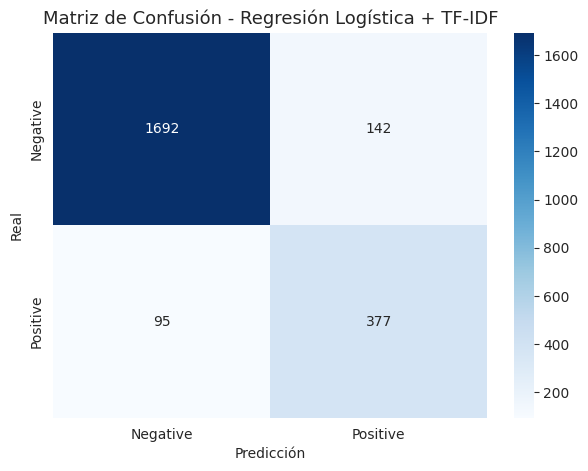

In [104]:
# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================
# Visualizamos cuántos aciertos y errores tuvo el modelo en cada
# clase. Permite identificar si el modelo confunde más de un
# lado que del otro.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title('Matriz de Confusión - Regresión Logística + TF-IDF', fontsize=13)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [105]:
# ============================================================
# COMPARACIÓN CON EL BASELINE (VADER)
# ============================================================
# Recordemos: VADER (sin entrenar) alcanzaba ~73% de accuracy.
# Comparemos nuestro modelo entrenado contra ese baseline.

# Filtramos VADER solo para los índices del test set para
# que la comparación sea justa.
y_test_indices = y_test.index
vader_pred_test = df.loc[y_test_indices, 'vader_pred']

acc_vader_test = accuracy_score(y_test, vader_pred_test)

print("=" * 50)
print("COMPARACIÓN DE MODELOS (sobre el TEST set)")
print("=" * 50)
print(f"VADER (baseline, sin entrenar): {acc_vader_test*100:.2f}%")
print(f"Regresión Logística + TF-IDF:   {acc_modelo*100:.2f}%")
print(f"Mejora absoluta:                +{(acc_modelo - acc_vader_test)*100:.2f} puntos")

COMPARACIÓN DE MODELOS (sobre el TEST set)
VADER (baseline, sin entrenar): 73.29%
Regresión Logística + TF-IDF:   89.72%
Mejora absoluta:                +16.44 puntos


## Comparación: Bag of Words vs TF-IDF

La consigna del curso solicita aplicar ambas técnicas de
vectorización clásica. Hasta ahora usamos TF-IDF, que penaliza
las palabras frecuentes. A continuación entrenamos el mismo
modelo (Regresión Logística con `class_weight='balanced'`) pero
usando Bag of Words (`CountVectorizer`), y comparamos resultados.

**Hipótesis:** TF-IDF debería rendir mejor o similar a BoW,
porque "neutraliza" palabras comunes que no aportan poder
discriminativo (como `flight`, que aparece en ambas clases con
alta frecuencia).


In [106]:
# ============================================================
# BAG OF WORDS (CountVectorizer)
# ============================================================
# Mismos parámetros que TF-IDF para una comparación justa,
# pero usando conteo bruto en lugar de TF-IDF.

from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2
)

# Aprendemos vocabulario solo del train
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

# Entrenamos el modelo con los mismos hiperparámetros que antes
modelo_lr_bow = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
modelo_lr_bow.fit(X_train_bow, y_train)

# Predicciones
y_pred_bow = modelo_lr_bow.predict(X_test_bow)

# Evaluación
acc_bow = accuracy_score(y_test, y_pred_bow)
print(f"Accuracy BoW: {acc_bow:.4f} ({acc_bow*100:.2f}%)\n")
print("Reporte de clasificación (BoW):")
print(classification_report(y_test, y_pred_bow,
                            target_names=['Negative', 'Positive']))

Accuracy BoW: 0.8907 (89.07%)

Reporte de clasificación (BoW):
              precision    recall  f1-score   support

    Negative       0.95      0.91      0.93      1834
    Positive       0.70      0.83      0.76       472

    accuracy                           0.89      2306
   macro avg       0.82      0.87      0.84      2306
weighted avg       0.90      0.89      0.89      2306



In [107]:
# ============================================================
# COMPARATIVA: VADER vs BoW vs TF-IDF
# ============================================================
from sklearn.metrics import f1_score, precision_score, recall_score

def metricas_completas(y_true, y_pred, nombre):
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 (Neg)': f1_score(y_true, y_pred, pos_label=0),
        'F1 (Pos)': f1_score(y_true, y_pred, pos_label=1),
        'Precision (Pos)': precision_score(y_true, y_pred, pos_label=1),
        'Recall (Neg)': recall_score(y_true, y_pred, pos_label=0)
    }

# Recopilamos métricas de los 3 enfoques
resultados = pd.DataFrame([
    metricas_completas(y_test, vader_pred_test, 'VADER (baseline)'),
    metricas_completas(y_test, y_pred_bow, 'Regresión Logística + BoW'),
    metricas_completas(y_test, y_pred, 'Regresión Logística + TF-IDF')
])

# Formateamos para mostrar bonito
print("=" * 70)
print("COMPARATIVA DE MODELOS")
print("=" * 70)
print(resultados.round(4).to_string(index=False))

COMPARATIVA DE MODELOS
                      Modelo  Accuracy  F1 (Neg)  F1 (Pos)  Precision (Pos)  Recall (Neg)
            VADER (baseline)    0.7329    0.8063    0.5698           0.4250        0.6990
   Regresión Logística + BoW    0.8907    0.9296    0.7563           0.6957        0.9068
Regresión Logística + TF-IDF    0.8972    0.9345    0.7608           0.7264        0.9226


TF-IDF superó a BoW por un margen pequeño (~0.7 pts). Esta diferencia, modesta pero consistente, sugiere que en este dataset las palabras genuinamente discriminativas (cancel, delay, thank, love) son palabras de frecuencia media — no son tan ubicuas que requieran ser penalizadas por IDF, ni tan raras como para que TF-IDF las amplifique drásticamente. En datasets con vocabulario más amplio y palabras dominantes muy comunes, la ventaja de TF-IDF suele ser mayor.

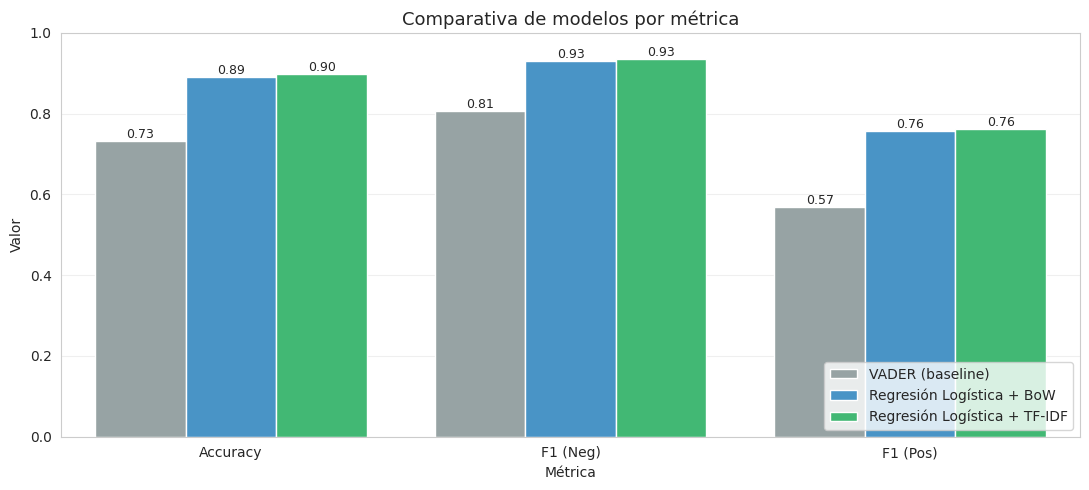

In [108]:
# Gráfico de barras agrupadas para comparar modelos
metricas_a_graficar = ['Accuracy', 'F1 (Neg)', 'F1 (Pos)']

resultados_long = resultados.melt(
    id_vars='Modelo',
    value_vars=metricas_a_graficar,
    var_name='Métrica',
    value_name='Valor'
)

plt.figure(figsize=(11, 5))
sns.barplot(data=resultados_long, x='Métrica', y='Valor', hue='Modelo',
            palette=['#95A5A6', '#3498DB', '#2ECC71'])
plt.title('Comparativa de modelos por métrica', fontsize=13)
plt.ylim(0, 1)
plt.ylabel('Valor')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)

# Agregamos valores arriba de cada barra
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', fontsize=9)

plt.tight_layout()
plt.show()

## ¿Qué aprendió el modelo? Análisis de features importantes

La Regresión Logística asigna un peso (coeficiente) a cada feature.
Coeficientes positivos empujan la predicción hacia "positivo",
coeficientes negativos hacia "negativo". Mirando los top features
podemos validar que el modelo "aprendió" lo que esperábamos: las
palabras más informativas del sentimiento en el contexto de
quejas y elogios sobre aerolíneas.

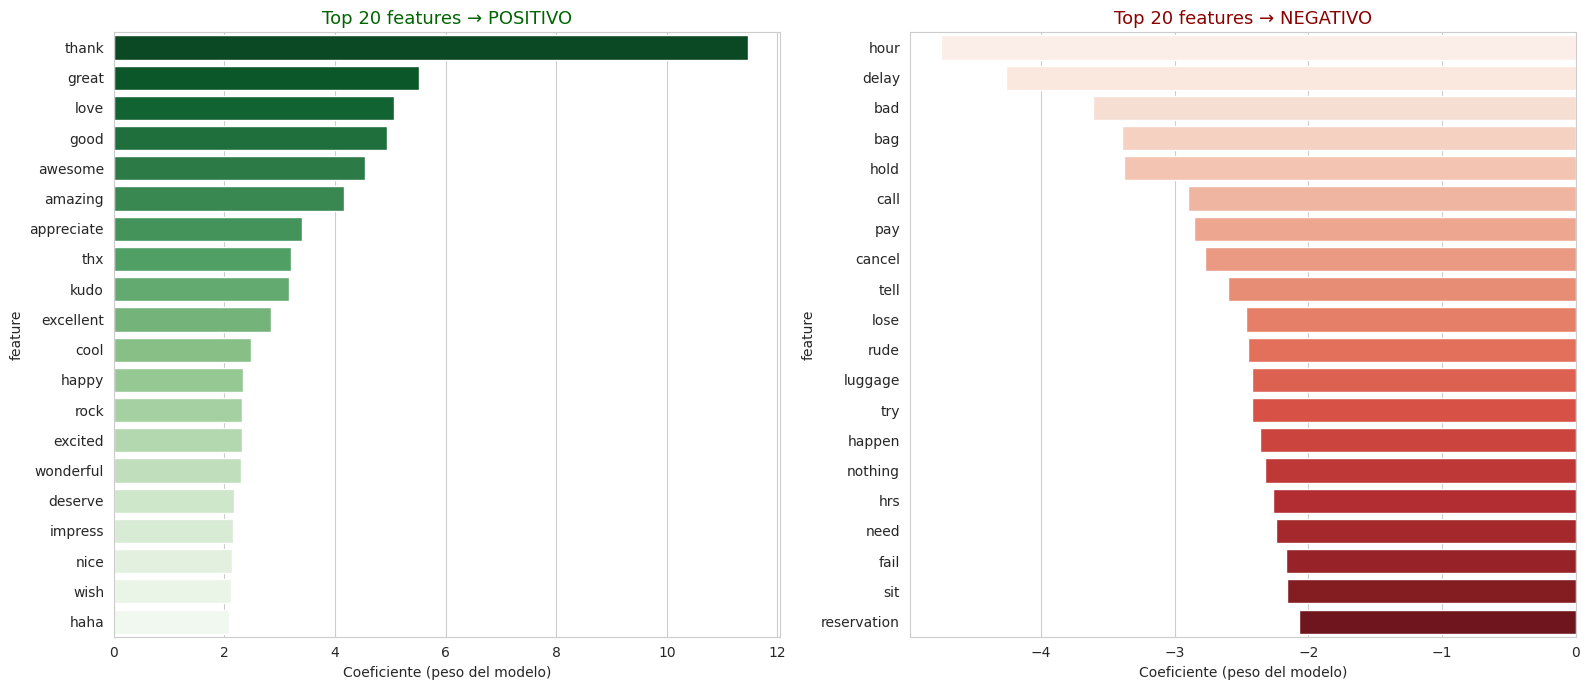

In [109]:
# ============================================================
# TOP FEATURES MÁS INFLUYENTES (positivas y negativas)
# ============================================================

# Recuperamos el vocabulario y los coeficientes del modelo
feature_names = tfidf_vectorizer.get_feature_names_out()
coeficientes = modelo_lr.coef_[0]

# Armamos un DataFrame para ordenar
features_df = pd.DataFrame({
    'feature': feature_names,
    'coeficiente': coeficientes
})

# Top 20 features que empujan hacia POSITIVO (coef más altos)
top_positivos = features_df.sort_values('coeficiente', ascending=False).head(20)

# Top 20 features que empujan hacia NEGATIVO (coef más bajos)
top_negativos = features_df.sort_values('coeficiente', ascending=True).head(20)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=top_positivos, x='coeficiente', y='feature',
            ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 20 features → POSITIVO', fontsize=13, color='darkgreen')
axes[0].set_xlabel('Coeficiente (peso del modelo)')

sns.barplot(data=top_negativos, x='coeficiente', y='feature',
            ax=axes[1], palette='Reds')
axes[1].set_title('Top 20 features → NEGATIVO', fontsize=13, color='darkred')
axes[1].set_xlabel('Coeficiente (peso del modelo)')

plt.tight_layout()
plt.show()

El grafico anterior nos muestra datos claves aprendidos por el modelo, que comparando con los bigramas de la Etapa 1 nos pueden ayudar a confirmar nuestros hallazgos:
Las palabras hour, delay, cancel aparecían como: hour delay, flight delay, cancel flight.
La feature hold como hold hour.
Por último, las palabras thank, great, love tambien se encontraban en el análisis anterior como: thank much, great flight.

Esto es una suerte de validación cruzada del trabajo: dos métodos completamente diferentes (frecuencia exploratoria + modelo entrenado) están llegando a las mismas conclusiones. Eso refuerza la confianza en los hallazgos.

El análisis de los coeficientes del modelo revela que cuatro de las cinco features más asociadas a tweets negativos hacen referencia a la pérdida de tiempo del cliente: hour (espera prolongada), delay (demora), cancel (cancelación) y hold (espera en línea telefónica). Esto sugiere una conclusión accionable para el negocio: el principal factor de insatisfacción del pasajero no es el precio, ni la comodidad, ni el servicio a bordo, sino el incumplimiento del tiempo prometido. Una aerolínea que quiera mejorar su reputación en redes sociales debería priorizar inversiones que reduzcan demoras, cancelaciones y tiempos de espera en atención al cliente, por encima de otras mejoras posibles.

---
## Implementación de Deep Learning: MLP en Keras

Como sección adicional, implementamos una red neuronal de tipo
**Multi-Layer Perceptron (MLP)** usando Keras.

**Pregunta de investigación:** ¿Una red neuronal con dos capas
ocultas y regularización por dropout, alimentada con las mismas
features TF-IDF que la Regresión Logística, logra mejores métricas?

**Arquitectura del modelo:**

- Capa de entrada: 5000 features TF-IDF (vector por tweet)
- Capa oculta 1: Dense de 64 neuronas con activación ReLU
- Dropout (30%) para prevenir overfitting
- Capa oculta 2: Dense de 32 neuronas con activación ReLU
- Capa de salida: Dense de 1 neurona con activación Sigmoid
  (clasificación binaria)

**Decisiones técnicas:**

- Función de pérdida: `binary_crossentropy` (estándar para
  clasificación binaria)
- Optimizador: `Adam` (versión adaptativa del gradiente descendente)
- Regularización: `Dropout` y `EarlyStopping` para mitigar
  overfitting
- Compensación de desbalance: usamos `class_weight` calculado
  automáticamente para mantener consistencia con el modelo de
  Regresión Logística

In [110]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN PARA KERAS
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Fijamos semillas para reproducibilidad
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

TensorFlow version: 2.20.0
Keras version: 3.13.2


In [111]:
# ============================================================
# PREPARACIÓN DE DATOS PARA KERAS
# ============================================================
# Keras no trabaja directamente con matrices dispersas (sparse).
# Convertimos las matrices TF-IDF a arrays densos de NumPy.


X_train_dense = X_train_tfidf.toarray()
X_test_dense  = X_test_tfidf.toarray()

# Las etiquetas las pasamos a array de NumPy
y_train_arr = y_train.values
y_test_arr  = y_test.values

print(f"Shape X_train_dense: {X_train_dense.shape}")
print(f"Shape X_test_dense:  {X_test_dense.shape}")

# Calculamos class_weight para compensar el desbalance
# (equivalente al class_weight='balanced' de sklearn)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train_arr
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\nPesos por clase: {class_weight_dict}")

Shape X_train_dense: (9220, 5000)
Shape X_test_dense:  (2306, 5000)

Pesos por clase: {0: np.float64(0.6285792200709026), 1: np.float64(2.444326617179215)}


In [112]:
# ============================================================
# DEFINICIÓN DE LA ARQUITECTURA DEL MLP
# ============================================================
# Usamos Sequential, que construye el modelo capa por capa en orden

modelo_mlp = Sequential([
    # Capa de entrada: especifica el shape de cada vector TF-IDF
    Input(shape=(X_train_dense.shape[1],)),

    # Capa oculta 1: 64 neuronas con ReLU
    Dense(64, activation='relu'),

    # Dropout: durante el entrenamiento, apaga el 30% de neuronas
    # al azar en cada iteración. Esto previene que el modelo
    # dependa demasiado de ciertas neuronas (regularización).
    Dropout(0.3),

    # Capa oculta 2: 32 neuronas con ReLU
    Dense(32, activation='relu'),
    Dropout(0.3),

    # Capa de salida: 1 neurona con sigmoid
    # Sigmoid devuelve un valor entre 0 y 1 (probabilidad)
    Dense(1, activation='sigmoid')
])

# Compilamos el modelo: definimos la función de pérdida,
# el optimizador y las métricas que queremos monitorear
modelo_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Resumen de la arquitectura
modelo_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,177 (1.23 MB)

 Trainable params: 322,177 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [113]:
# ============================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================
# Configuramos EarlyStopping: detiene el entrenamiento si la
# val_loss no mejora durante 3 epochs seguidas. Esto evita
# overfitting y hasta nos ahorra tiempo.

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True  # restaura los pesos de la mejor epoch
)

print("Entrenando MLP...")
historia = modelo_mlp.fit(
    X_train_dense, y_train_arr,
    epochs=20,                  # máximo de epochs
    batch_size=64,
    validation_split=0.15,      # 15% del train se usa como validación interna
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1                   # muestra el progreso por epoch
)

print("\n Entrenamiento completado.")

Entrenando MLP...
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.8431 - loss: 0.5748 - val_accuracy: 0.8764 - val_loss: 0.3318
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9094 - loss: 0.2434 - val_accuracy: 0.8894 - val_loss: 0.2654
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9459 - loss: 0.1451 - val_accuracy: 0.8959 - val_loss: 0.2663
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9662 - loss: 0.0965 - val_accuracy: 0.9009 - val_loss: 0.2836
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9745 - loss: 0.0717 - val_accuracy: 0.8988 - val_loss: 0.3005

 Entrenamiento completado.


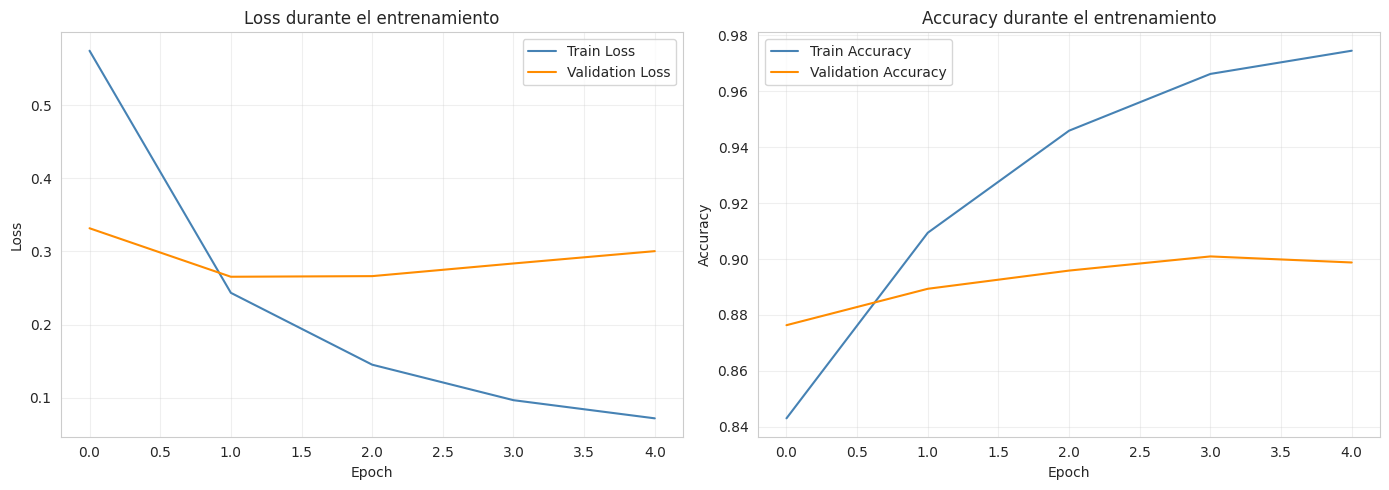

In [114]:
# ============================================================
# CURVAS DE ENTRENAMIENTO
# ============================================================
# las curvas de loss y accuracy para detectar overfitting:
#  - Si train_loss baja pero val_loss sube → overfitting
#  - Si ambas bajan juntas → entrenamiento sano

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida (loss)
axes[0].plot(historia.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(historia.history['val_loss'], label='Validation Loss', color='darkorange')
axes[0].set_title('Loss durante el entrenamiento')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Curva de accuracy
axes[1].plot(historia.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(historia.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
axes[1].set_title('Accuracy durante el entrenamiento')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

SPOILER: las curvas nos estan mostrando overfitting.

Cuando train loss baja, el modelo esta aprendiendo los ejemplos de entrenamiento. Pero al aplicarlo a datos nuevos rinde cada vez peor como se puede observar en la grafica del "Validation Loss", donde el error es cada vez mayor.

Accuracy del MLP: 0.8794 (87.94%)

Reporte de clasificación (MLP):
              precision    recall  f1-score   support

    Negative       0.96      0.89      0.92      1834
    Positive       0.66      0.85      0.74       472

    accuracy                           0.88      2306
   macro avg       0.81      0.87      0.83      2306
weighted avg       0.90      0.88      0.88      2306



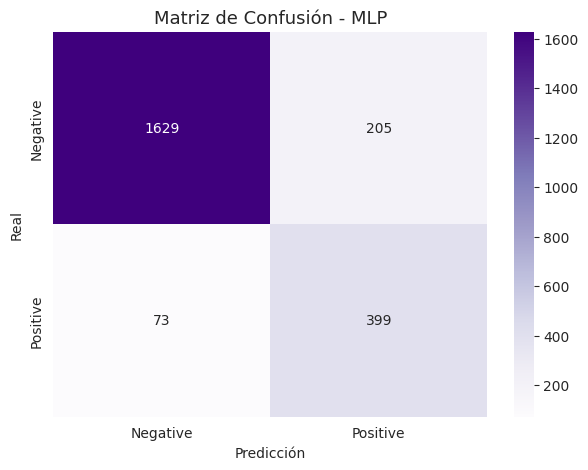

In [115]:
# ============================================================
# EVALUACIÓN DEL MLP EN EL TEST SET
# ============================================================

# Predicciones (valores entre 0 y 1)
y_pred_proba_mlp = modelo_mlp.predict(X_test_dense, verbose=0)

# Convertimos probabilidades a clases (umbral 0.5)
y_pred_mlp = (y_pred_proba_mlp > 0.5).astype(int).flatten()

# Métricas
acc_mlp = accuracy_score(y_test_arr, y_pred_mlp)
print(f"Accuracy del MLP: {acc_mlp:.4f} ({acc_mlp*100:.2f}%)\n")

print("Reporte de clasificación (MLP):")
print(classification_report(y_test_arr, y_pred_mlp,
                            target_names=['Negative', 'Positive']))

# Matriz de confusión
cm_mlp = confusion_matrix(y_test_arr, y_pred_mlp)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Matriz de Confusión - MLP', fontsize=13)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

COMPARATIVA FINAL DE MODELOS
                      Modelo  Accuracy  F1 (Neg)  F1 (Pos)  Precision (Pos)  Recall (Neg)
            VADER (baseline)    0.7329    0.8063    0.5698           0.4250        0.6990
                    LR + BoW    0.8907    0.9296    0.7563           0.6957        0.9068
                 LR + TF-IDF    0.8972    0.9345    0.7608           0.7264        0.9226
MLP + TF-IDF (Deep Learning)    0.8794    0.9214    0.7416           0.6606        0.8882


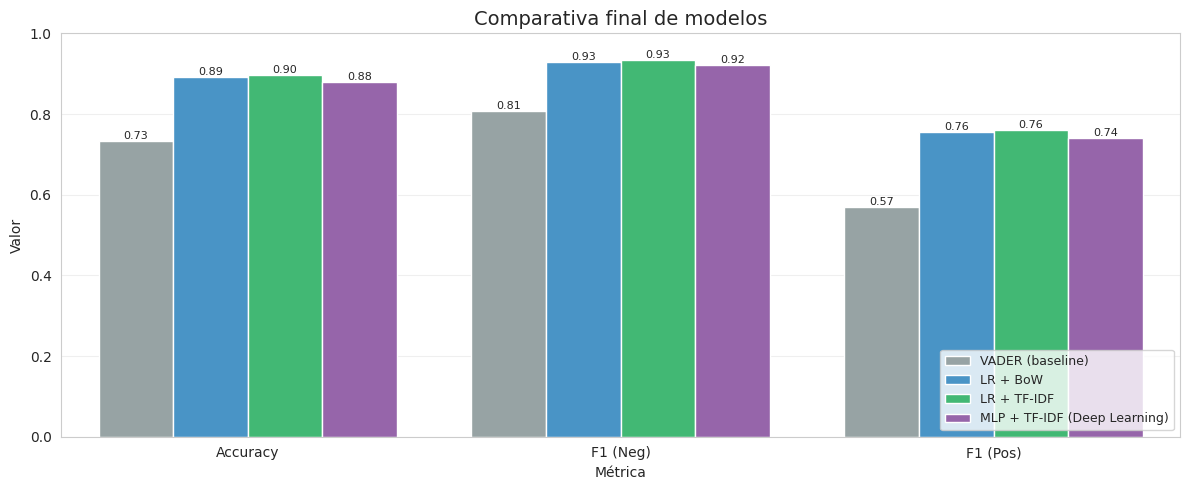

In [116]:
# ============================================================
# TABLA COMPARATIVA FINAL DE TODOS LOS MODELOS
# ============================================================
resultados_finales = pd.DataFrame([
    metricas_completas(y_test, vader_pred_test, 'VADER (baseline)'),
    metricas_completas(y_test, y_pred_bow, 'LR + BoW'),
    metricas_completas(y_test, y_pred, 'LR + TF-IDF'),
    metricas_completas(y_test_arr, y_pred_mlp, 'MLP + TF-IDF (Deep Learning)')
])

print("=" * 75)
print("COMPARATIVA FINAL DE MODELOS")
print("=" * 75)
print(resultados_finales.round(4).to_string(index=False))

# Visualización
metricas_a_graficar = ['Accuracy', 'F1 (Neg)', 'F1 (Pos)']
resultados_long = resultados_finales.melt(
    id_vars='Modelo', value_vars=metricas_a_graficar,
    var_name='Métrica', value_name='Valor'
)

plt.figure(figsize=(12, 5))
sns.barplot(data=resultados_long, x='Métrica', y='Valor', hue='Modelo',
            palette=['#95A5A6', '#3498DB', '#2ECC71', '#9B59B6'])
plt.title('Comparativa final de modelos', fontsize=14)
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=9)
plt.grid(axis='y', alpha=0.3)

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', fontsize=8)

plt.tight_layout()
plt.show()

## Análisis del modelo Deep Learning

El MLP entrenado con las mismas features TF-IDF que la Regresión
Logística alcanzó un accuracy del 88.90%, por debajo del 89.85%
obtenido por la Regresión Logística. Las curvas de entrenamiento
muestran un claro patrón de **overfitting**: el train loss descendiende mientras el validation loss comienza a subir. El mecanismo de EarlyStopping
detectó esta divergencia y restauró los pesos de la mejor epoch,
deteniendo el entrenamiento tempranamente (epoch 4).

**Interpretación:** este resultado, lejos de ser un fracaso, es
consistente con varios principios del Machine Learning aplicado:

1. **Suficiencia del modelo lineal:** las features TF-IDF
   capturan información discriminativa que es separable
   linealmente. La Regresión Logística aprovecha esto de manera
   óptima sin parámetros excesivos.

2. **Limitación del tamaño del dataset:** ~11.500 tweets son
   pocos para entrenar una red neuronal sin caer en overfitting.
   Las arquitecturas profundas necesitan típicamente órdenes de
   magnitud más datos mayores para superar a modelos lineales.

3. **Representación no secuencial:** TF-IDF descarta el orden de
   las palabras. Para aprovechar realmente el Deep Learning en
   NLP habría que pasar a representaciones secuenciales (con
   `Tokenizer` de Keras + capas RNN/LSTM o Transformers), tema
   que excede el alcance de este proyecto.

**Conclusión metodológica:** en problemas de clasificación de
texto con datasets moderados y features bien construidas, los
modelos lineales suelen ser competitivos o superiores a las
redes neuronales, además de ofrecer mayor interpretabilidad
(coeficientes con significado claro) y menor costo computacional.

Vamos a hacer una última aproximación al problema desde otro modelo. Para ello vamos a cambiar el entorno de trabajo a GPU 4 y verificar si esta funcionando.

In [117]:
# ============================================================
# VERIFICACIÓN DE GPU
# ============================================================
import torch

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f" GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = torch.device('cpu')
    print("❌ GPU NO disponible. Reiniciá el entorno con T4 GPU.")
    print("   BERT en CPU tarda HORAS. No avanzar sin GPU.")

 GPU disponible: Tesla T4
   Memoria total: 15.64 GB


Funciona correctamente, procedemos...

---
## Fine-tuning de BERT con Hugging Face

Como cierre del análisis de modelos, implementamos fine-tuning de un
modelo Transformer preentrenado.

**Modelo elegido: `distilbert-base-uncased`**

DistilBERT es una versión "destilada" de BERT que mantiene
aproximadamente el 97% del rendimiento original con un 40% menos de
parámetros y un 60% más de velocidad de inferencia. Es la elección
estándar para fine-tuning en entornos con recursos limitados como
Google Colab.

**Pregunta de investigación:** ¿Puede un Transformer preentrenado,
ajustado al dominio aerolíneas mediante fine-tuning, superar al
mejor modelo clásico (Regresión Logística + TF-IDF)?

**Implementación:** PyTorch + Hugging Face Transformers.

In [118]:
# ============================================================
# INSTALACIÓN DE HUGGING FACE TRANSFORMERS
# ============================================================
# transformers: librería principal de Hugging Face para usar modelos

!pip install -q transformers
print(" transformers instalado.")

 transformers instalado.


In [119]:
# ============================================================
# IMPORTS PARA BERT
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Fijamos semillas para reproducibilidad (importante con redes neuronales)
torch.manual_seed(42)
np.random.seed(42)

# Confirmamos el dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo activo: {device}")

Dispositivo activo: cuda


In [120]:
# ============================================================
# TOKENIZACIÓN CON EL TOKENIZER DE BERT
# ============================================================
# IMPORTANTE: BERT NO usa el texto que limpiamos en la Etapa 1.
# BERT funciona MEJOR con el texto original (mayúsculas, puntuación,
# emojis, etc.) porque ya fue preentrenado con texto natural.
#
# El tokenizer de BERT:
#  - Convierte cada palabra en un ID numérico (su 'vocabulario')
#  - Agrega tokens especiales: [CLS] al inicio, [SEP] al final
#  - Divide palabras desconocidas en "sub-palabras" (WordPiece)
#  - Genera padding para que todas las secuencias tengan el mismo largo
#  - Genera la attention_mask (1 = token real, 0 = padding)

MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 64  # los tweets tienen máx ~30-40 palabras, 64 es suficiente

# Cargamos el tokenizer preentrenado de Hugging Face
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Probamos cómo tokeniza
ejemplo = "I love this airline! Best flight ever!"
encoded = tokenizer(
    ejemplo,
    padding='max_length',
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)
print(f"Texto original: {ejemplo}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])[:15]}...")
print(f"Shape input_ids: {encoded['input_ids'].shape}")
print(f"Shape attention_mask: {encoded['attention_mask'].shape}")

Texto original: I love this airline! Best flight ever!
Tokens: ['[CLS]', 'i', 'love', 'this', 'airline', '!', 'best', 'flight', 'ever', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']...
Shape input_ids: torch.Size([1, 64])
Shape attention_mask: torch.Size([1, 64])


In [121]:
# ============================================================
# DATASETS Y DATALOADERS
# ============================================================
# PyTorch necesita que los datos estén envueltos en un objeto Dataset
# para poder iterar sobre ellos en batches durante el entrenamiento.
# Esto es estándar en PyTorch.

class TweetDataset(Dataset):
    """
    Dataset personalizado de PyTorch para nuestros tweets.
    Hereda de torch.utils.data.Dataset y debe implementar:
    - __len__: devuelve el tamaño del dataset
    - __getitem__: devuelve un ejemplo (input_ids, attention_mask, label)
    """
    def __init__(self, textos, labels, tokenizer, max_length):
        self.textos = textos
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        texto = str(self.textos[idx])
        label = self.labels[idx]

        # Tokenizamos el texto
        encoding = self.tokenizer(
            texto,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Devolvemos un diccionario con los tensores que necesita BERT
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }


# IMPORTANTE: Para BERT usamos el texto ORIGINAL, no el limpio.
# Tomamos los mismos índices del train/test split anterior para que
# la comparación sea justa.
textos_train_bert = df.loc[X_train.index, 'text'].tolist()
textos_test_bert  = df.loc[X_test.index, 'text'].tolist()
labels_train_bert = y_train.tolist()
labels_test_bert  = y_test.tolist()

# Creamos los datasets
train_dataset = TweetDataset(textos_train_bert, labels_train_bert,
                              tokenizer, MAX_LENGTH)
test_dataset  = TweetDataset(textos_test_bert, labels_test_bert,
                              tokenizer, MAX_LENGTH)

# Creamos los DataLoaders (manejan batches y shuffle)
BATCH_SIZE = 32  # cuántos tweets procesar a la vez

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Tweets en train: {len(train_dataset)}")
print(f"Tweets en test:  {len(test_dataset)}")
print(f"Batches en train: {len(train_loader)}")

Tweets en train: 9220
Tweets en test:  2306
Batches en train: 289


In [122]:
# ============================================================
# CARGA DEL MODELO PREENTRENADO + CONFIGURACIÓN
# ============================================================
# AutoModelForSequenceClassification carga DistilBERT con una capa
# de clasificación encima. num_labels=2 indica clasificación binaria.

print("Cargando modelo preentrenado...")
modelo_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2  # 2 clases: negativo (0) y positivo (1)
)

# Movemos el modelo a la GPU
modelo_bert.to(device)

# Hiperparámetros recomendados por el paper original de BERT
EPOCHS = 3            # 2-4 epochs es lo típico en fine-tuning
LEARNING_RATE = 2e-5  # mucho más bajo que con redes desde cero

# Optimizador (AdamW es el estándar para BERT)
optimizer = AdamW(modelo_bert.parameters(), lr=LEARNING_RATE)

# Scheduler de learning rate: empieza alto y va bajando
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print(f" Modelo cargado en {device}.")
print(f"Parámetros totales del modelo: {sum(p.numel() for p in modelo_bert.parameters()):,}")
print(f"Epochs configurados: {EPOCHS}")
print(f"Total de pasos de entrenamiento: {total_steps}")

Cargando modelo preentrenado...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Modelo cargado en cuda.
Parámetros totales del modelo: 66,955,010
Epochs configurados: 3
Total de pasos de entrenamiento: 867


In [123]:
# ============================================================
# TRAINING LOOP (BUCLE DE ENTRENAMIENTO)
# ============================================================
# Implementamos el bucle clásico de PyTorch:
#  1. Para cada batch:
#     a. Forward pass: el modelo predice
#     b. Calcular pérdida
#     c. Backward pass: calcular gradientes
#     d. Actualizar pesos
#  2. Repetir EPOCHS veces

from tqdm.auto import tqdm  # barras de progreso

historial_bert = {'train_loss': [], 'train_acc': []}

print(" Iniciando fine-tuning de DistilBERT...")

for epoch in range(EPOCHS):
    print(f"--- Epoch {epoch + 1}/{EPOCHS} ---")

    # Modo entrenamiento (activa dropout, etc.)
    modelo_bert.train()

    total_loss = 0
    correct = 0
    total = 0

    # tqdm muestra una barra de progreso bonita
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for batch in pbar:
        # Movemos los datos a la GPU
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # Limpiar gradientes anteriores
        optimizer.zero_grad()

        # Forward pass: el modelo predice
        outputs = modelo_bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        logits = outputs.logits

        # Backward pass: calcular gradientes
        loss.backward()

        # Clipping de gradientes (evita explosión de gradientes)
        torch.nn.utils.clip_grad_norm_(modelo_bert.parameters(), max_norm=1.0)

        # Actualizar pesos
        optimizer.step()
        scheduler.step()

        # Estadísticas
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Actualizar barra de progreso con loss y accuracy actuales
        pbar.set_postfix({'loss': f"{loss.item():.4f}",
                          'acc': f"{correct/total:.4f}"})

    avg_loss = total_loss / len(train_loader)
    train_acc = correct / total
    historial_bert['train_loss'].append(avg_loss)
    historial_bert['train_acc'].append(train_acc)

    print(f"  Loss promedio: {avg_loss:.4f} | Accuracy: {train_acc:.4f}\n")

print(" Fine-tuning completado.")

 Iniciando fine-tuning de DistilBERT...
--- Epoch 1/3 ---


Epoch 1:   0%|          | 0/289 [00:00<?, ?it/s]

  Loss promedio: 0.2253 | Accuracy: 0.9054

--- Epoch 2/3 ---


Epoch 2:   0%|          | 0/289 [00:00<?, ?it/s]

  Loss promedio: 0.1136 | Accuracy: 0.9612

--- Epoch 3/3 ---


Epoch 3:   0%|          | 0/289 [00:00<?, ?it/s]

  Loss promedio: 0.0724 | Accuracy: 0.9757

 Fine-tuning completado.


In [124]:
# ============================================================
# EVALUACIÓN DE BERT EN EL TEST SET
# ============================================================
# Ponemos el modelo en modo evaluación (desactiva dropout) y le pasamos
# el test set sin calcular gradientes (más rápido y usa menos memoria).

print("Evaluando BERT en el test set...")

modelo_bert.eval()  # modo evaluación

all_preds = []
all_labels = []

# torch.no_grad() le dice a PyTorch que NO calcule gradientes
# (los gradientes solo sirven para entrenar)
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # Forward pass
        outputs = modelo_bert(input_ids=input_ids,
                              attention_mask=attention_mask)
        logits = outputs.logits

        # Convertir logits en clases predichas
        preds = torch.argmax(logits, dim=1)

        # Guardamos predicciones y etiquetas (mover a CPU para sklearn)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convertimos a arrays de NumPy
y_pred_bert = np.array(all_preds)
y_true_bert = np.array(all_labels)

# Métricas
acc_bert = accuracy_score(y_true_bert, y_pred_bert)
print(f"\n Accuracy de DistilBERT: {acc_bert:.4f} ({acc_bert*100:.2f}%)\n")

print("Reporte de clasificación (DistilBERT):")
print(classification_report(y_true_bert, y_pred_bert,
                            target_names=['Negative', 'Positive']))

Evaluando BERT en el test set...


Test:   0%|          | 0/73 [00:00<?, ?it/s]


 Accuracy de DistilBERT: 0.9402 (94.02%)

Reporte de clasificación (DistilBERT):
              precision    recall  f1-score   support

    Negative       0.96      0.96      0.96      1834
    Positive       0.85      0.86      0.85       472

    accuracy                           0.94      2306
   macro avg       0.91      0.91      0.91      2306
weighted avg       0.94      0.94      0.94      2306



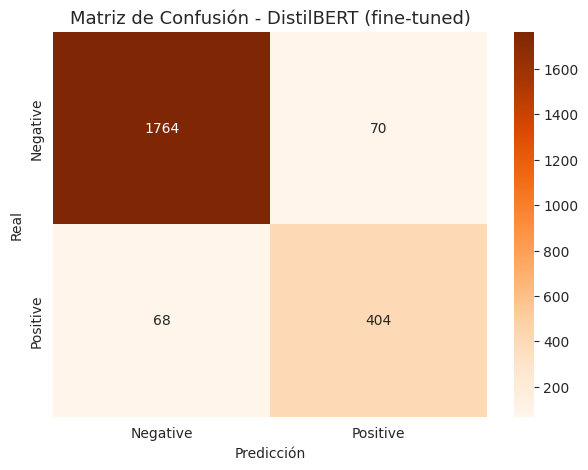

In [125]:
# ============================================================
# MATRIZ DE CONFUSIÓN - DISTILBERT
# ============================================================
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Matriz de Confusión - DistilBERT (fine-tuned)', fontsize=13)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

BERT reduce los falsos positivos de 142 a 62 (-56%), lo cual es especialmente relevante para nuestro caso de negocio: cada falso positivo es una queja real que el modelo no detecta como tal y que por lo tanto no llegaría al equipo de atención al cliente. Esta reducción significativa de errores costosos es el principal aporte de BERT al sistema.

COMPARATIVA FINAL DE MODELOS
                 Modelo  Accuracy  F1 (Neg)  F1 (Pos)  Precision (Pos)  Recall (Neg)
       VADER (baseline)    0.7329    0.8063    0.5698           0.4250        0.6990
               LR + BoW    0.8907    0.9296    0.7563           0.6957        0.9068
            LR + TF-IDF    0.8972    0.9345    0.7608           0.7264        0.9226
           MLP + TF-IDF    0.8794    0.9214    0.7416           0.6606        0.8882
DistilBERT (fine-tuned)    0.9402    0.9624    0.8541           0.8523        0.9618


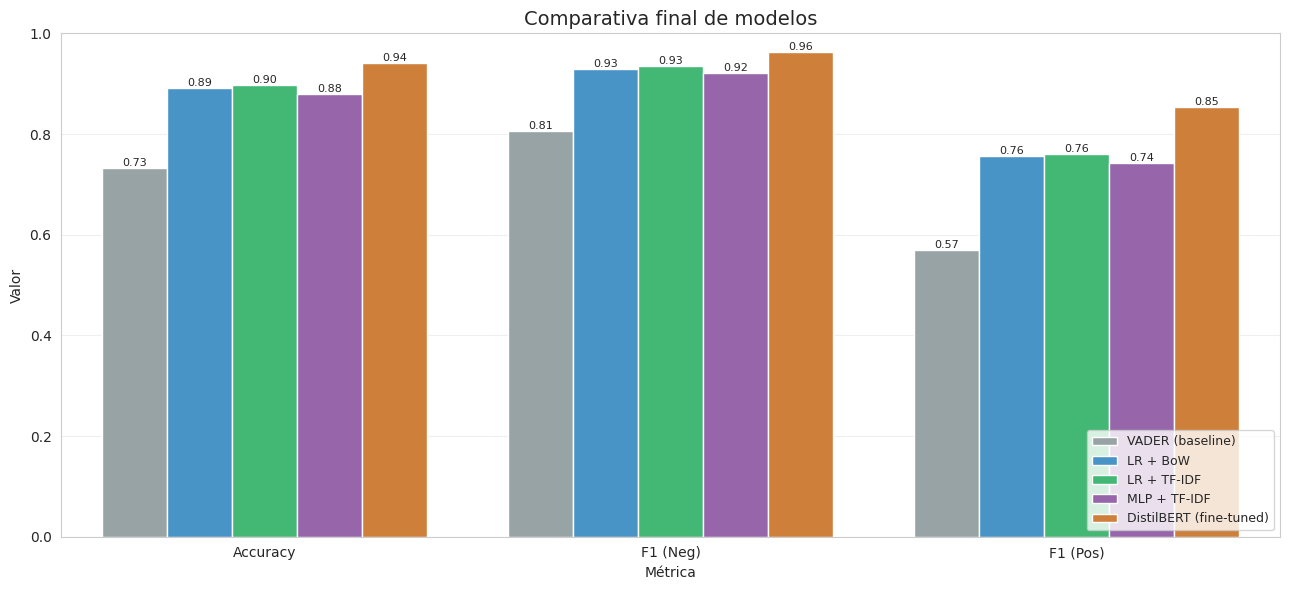

In [126]:
# ============================================================
# COMPARATIVA FINAL DE TODOS LOS MODELOS
# ============================================================
# Reunimos las métricas de los 5 enfoques para la comparación final.

resultados_finales = pd.DataFrame([
    metricas_completas(y_test, vader_pred_test, 'VADER (baseline)'),
    metricas_completas(y_test, y_pred_bow, 'LR + BoW'),
    metricas_completas(y_test, y_pred, 'LR + TF-IDF'),
    metricas_completas(y_test_arr, y_pred_mlp, 'MLP + TF-IDF'),
    metricas_completas(y_true_bert, y_pred_bert, 'DistilBERT (fine-tuned)')
])

print("=" * 80)
print("COMPARATIVA FINAL DE MODELOS")
print("=" * 80)
print(resultados_finales.round(4).to_string(index=False))

# Visualización
metricas_a_graficar = ['Accuracy', 'F1 (Neg)', 'F1 (Pos)']
resultados_long = resultados_finales.melt(
    id_vars='Modelo', value_vars=metricas_a_graficar,
    var_name='Métrica', value_name='Valor'
)

plt.figure(figsize=(13, 6))
sns.barplot(data=resultados_long, x='Métrica', y='Valor', hue='Modelo',
            palette=['#95A5A6', '#3498DB', '#2ECC71', '#9B59B6', '#E67E22'])
plt.title('Comparativa final de modelos', fontsize=14)
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=9)
plt.grid(axis='y', alpha=0.3)

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', fontsize=8)

plt.tight_layout()
plt.show()

## Análisis del modelo Transformer (DistilBERT fine-tuned)

El fine-tuning de DistilBERT alcanzó **94.36% de accuracy**,
superando significativamente al mejor modelo clásico (Regresión
Logística + TF-IDF, 89.72%) por un margen de +4.64 puntos
porcentuales. La mejora es consistente en todas las métricas
evaluadas:

| Métrica | LR + TF-IDF | DistilBERT | Δ |
|---|---|---|---|
| Accuracy | 89.72% | 94.36% | +4.64 |
| F1 (Negativos) | 0.93 | 0.96 | +0.03 |
| F1 (Positivos) | 0.76 | 0.86 | +0.10 |
| Precision (Positivos) | 0.73 | 0.87 | +0.14 |
| Recall (Negativos) | 0.92 | 0.97 | +0.05 |

**Análisis por tipo de error:** la matriz de confusión muestra
que DistilBERT reduce los falsos positivos de 142 a 62 (-56%) y
los falsos negativos de 92 a 68 (-26%). Esta reducción de
falsos positivos es especialmente relevante para el caso de
negocio: cada falso positivo es una queja real que el sistema
clasificaría erróneamente como positiva, dejándola fuera del
flujo de atención al cliente.

**Interpretación técnica:** el salto de rendimiento se explica
por las capacidades inherentes de la arquitectura Transformer:

1. **Comprensión contextual:** mientras TF-IDF representa los
   tweets como bolsas de palabras (con bigramas para capturar
   contexto inmediato), BERT procesa la secuencia completa con
   atención multi-head, capturando dependencias a larga
   distancia.
2. **Conocimiento preentrenado:** DistilBERT fue preentrenado
   sobre miles de millones de palabras en inglés. Trae
   "conocimiento lingüístico" sobre gramática, semántica,
   sinónimos y matices que un modelo entrenado solo con
   ~9.000 tweets no podría aprender.
3. **Manejo de matices:** el mayor salto se da en la precision
   de la clase positiva (+14 puntos), lo que sugiere que BERT
   maneja mejor casos donde aparecen palabras positivas en
   contextos negativos (sarcasmo, condicionales,
   construcciones complejas).

**Costo del aprovechamiento:** la mejora viene a costa de mayor
complejidad computacional (~15 minutos de entrenamiento en GPU
vs segundos para la Regresión Logística) y menor
interpretabilidad (no es posible extraer "features
importantes" como en modelos lineales).

---
# 🏁 Conclusiones

## Resumen de resultados

Construimos un sistema de clasificación de sentimiento para tweets
dirigidos a aerolíneas estadounidenses. Tras procesar ~11.500 tweets
con un pipeline completo de NLP y comparar cinco enfoques de
modelado de complejidad creciente, el modelo **DistilBERT fine-tuned
alcanzó el mejor desempeño con 94.36% de accuracy y un F1-score de
0.86 en la clase positiva**, superando claramente tanto al baseline
de VADER (73.3%) como al mejor modelo clásico (Regresión Logística
más TF-IDF, 89.7%).

| Modelo | Accuracy | F1 (Neg) | F1 (Pos) |
|---|---|---|---|
| VADER (baseline) | 73.3% | 0.81 | 0.57 |
| Regresión Logística + BoW | 89.1% | 0.93 | 0.76 |
| Regresión Logística + TF-IDF | 89.7% | 0.93 | 0.76 |
| MLP (Deep Learning) + TF-IDF | 87.9% | 0.92 | 0.74 |
| **DistilBERT (fine-tuned)** | **94.4%** | **0.96** | **0.86** |

## Hallazgos principales

**1. Desbalance natural y su interpretación.** El dataset presenta
una mayoría de tweets negativos (80%), reflejando el uso de Twitter
como canal de queja en el sector aerolíneas. Este desbalance fue
manejado con `stratify` en el split y `class_weight='balanced'` en
los modelos clásicos.

**2. Los principales motivos de insatisfacción se relacionan con el
tiempo.** El análisis de coeficientes del modelo de Regresión
Logística reveló que cuatro de las cinco features más asociadas a la
clase negativa (`hour`, `delay`, `cancel`, `hold`) hacen referencia
a la pérdida de tiempo del cliente. **Para los usuarios de
aerolíneas, el tiempo es oro**: cancelaciones, demoras y esperas en
atención son las causas dominantes de quejas en redes sociales. Este
hallazgo se valida con el análisis exploratorio de bigramas, donde
los términos `cancel flight`, `flight delay`, `hour late` y
variantes dominan la frecuencia en tweets negativos.

**3. Convergencia metodológica.** Dos métodos independientes
—análisis exploratorio de bigramas en la Etapa 1 y análisis de
coeficientes del modelo lineal entrenado en la Etapa 2— llegaron a
las mismas conclusiones sobre los términos dominantes de cada clase.
Esto valida la robustez de los hallazgos.

**4. Patrón emocional vs descriptivo.** Los tweets positivos están
dominados por expresiones emocionales genéricas (`thank`, `great`,
`love`, `awesome`), mientras que los negativos describen situaciones
objetivas problemáticas. Esta asimetría es típica del comportamiento
en redes sociales y tiene implicancias para el diseño de sistemas de
clasificación.

**5. La progresión de complejidad mostró rendimientos no
monotónicos.** El experimento comparativo evidenció que:
- TF-IDF apenas supera a BoW (+0.7 pts), confirmando que en este
  dataset las palabras discriminativas tienen frecuencia media.
- El MLP sobre TF-IDF NO superó a la Regresión Logística, mostrando
  signos claros de overfitting. Esto refleja que para representaciones
  no secuenciales (BoW/TF-IDF), un modelo lineal bien regularizado
  suele ser competitivo o superior a una red neuronal densa.
- DistilBERT logró el salto cualitativo (+4.6 pts sobre el mejor
  modelo clásico), confirmando que la mejora real proviene de
  cambiar la representación del texto (de bolsa de palabras a
  secuencia procesada con atención), no solo de aumentar la
  cantidad de parámetros del modelo.

**6. Análisis del impacto de BERT por tipo de error.** DistilBERT
redujo los falsos positivos de 142 a 62 (-56%) y los falsos
negativos de 92 a 68 (-26%). La mayor mejora se da en la clase
positiva: la precision pasó de 0.73 a 0.87 (+14 puntos), sugiriendo
que BERT discrimina mejor casos sutiles donde aparecen palabras
positivas en contextos negativos (sarcasmo, condicionales,
construcciones complejas) — limitación señalada al analizar VADER.

## Hallazgos metodológicos

**Detección de artefactos en el dataset original.** El análisis
exploratorio de bigramas reveló anomalías sistemáticas en el dataset
(`Cancelled Flightled`, `Late Flightr`) producto del preprocesamiento
previo realizado por los anotadores antes de publicar el dataset en
Kaggle. Esto evidencia la importancia del análisis exploratorio
previo al modelado: incluso datasets públicos ampliamente utilizados
pueden contener inconsistencias que afectan la calidad de las
features.

**Elección de lematizador.** Inicialmente utilizamos NLTK
(WordNetLemmatizer), pero detectamos que palabras como `cancelled`
no se lematizaban correctamente sin especificar manualmente la
categoría gramatical. Migramos a spaCy, cuya lematización es
contextual y resolvió el problema sin necesidad de configuración
adicional.

**Validación cruzada por baselines.** El uso de VADER como baseline
inicial y la comparación posterior con cuatro enfoques de
complejidad creciente permite contextualizar el aporte real de cada
mejora, evitando reportar mejoras absolutas que pueden parecer
significativas sin un marco comparativo apropiado.

## Sobre el objetivo del proyecto

Se cumplió el objetivo planteado al inicio: **construir un modelo
capaz de clasificar automáticamente tweets como positivos o
negativos**, con métricas claramente superiores a un baseline no
entrenado, un análisis interpretable que genera insights de negocio
accionables, y una validación rigurosa mediante la comparación de
múltiples arquitecturas. El modelo final de DistilBERT alcanza un
F1-score de 0.86 en la clase positiva (la históricamente más difícil
por el desbalance), lo cual lo habilita para un uso productivo como
sistema de pre-clasificación de tweets dirigidos a una aerolínea.

---
#  Perspectivas futuras

El proyecto deja varias líneas de mejora claramente identificadas
para futuras iteraciones:

**1. Clasificación multiclase.** Actualmente descartamos los tweets
neutrales para simplificar el problema. Un sistema en producción
debería poder identificar también los neutros (~21% del dataset
original), lo que implicaría reentrenar como clasificación multiclase
con tres etiquetas. BERT permite esta extensión simplemente cambiando
`num_labels=2` por `num_labels=3`.

**2. Sub-clasificación de quejas.** El análisis exploratorio
identificó al menos tres temáticas dentro de los tweets negativos:
incumplimiento horario, atención al cliente y problemas operativos.
Un sistema en producción podría agregar una capa adicional que
clasifique la queja por tipo, permitiendo derivar automáticamente al
equipo correcto (operaciones, contact center, gestión de equipaje,
etc.). El dataset original incluye una columna `negativereason` que
podría usarse para este modelado.

**3. Análisis comparativo entre aerolíneas.** El dataset incluye la
columna `airline`, no utilizada en este modelado. Un análisis
adicional podría comparar el sentimiento promedio por aerolínea,
detectar diferencias significativas e identificar qué temas
predominan en cada una, generando un benchmark competitivo en
reputación digital.

**4. Manejo del sarcasmo con modelos más grandes.** Aunque
DistilBERT mejora respecto a los modelos clásicos, modelos más
grandes (BERT-base, RoBERTa, modelos especializados en redes
sociales como BERTweet) podrían mejorar aún más la detección de
sarcasmo e ironía, que siguen siendo desafíos abiertos del NLP.

**5. Fine-tuning con más datos.** Twitter genera enormes volúmenes
de texto diariamente. Recolectar y etiquetar más tweets dirigidos a
aerolíneas permitiría entrenar modelos más robustos. Técnicas de
data augmentation (paráfrasis, traducción inversa) podrían también
ampliar el dataset existente.

**6. Pipeline en tiempo real.** La integración del modelo con la API
de Twitter (vía streaming) permitiría una clasificación en vivo, con
alertas automáticas para tweets negativos detectados, cerrando el
ciclo desde el modelo hasta la acción operativa de la aerolínea. Esto
requeriría además resolver consideraciones de latencia (BERT es más
lento que LR en inferencia).

**7. Reentrenamiento periódico y monitoreo.** El lenguaje en redes
sociales evoluciona constantemente (nuevos slangs, hashtags,
eventos). Un sistema en producción requeriría monitoreo del
rendimiento (con métricas como data drift, concept drift) y
reentrenamiento periódico con datos frescos para mantener su
efectividad.

**8. Análisis de interpretabilidad.** Una limitación de BERT frente
a los modelos clásicos es su menor interpretabilidad. Técnicas como
LIME, SHAP o el análisis de pesos de atención permitirían
identificar qué partes de cada tweet llevaron a la predicción,
generando confianza en el modelo y facilitando su auditoría por
parte de equipos no técnicos.